# 06 - Análisis de satisfacción del cliente

## 1. Objetivo del notebook

Este notebook busca entender qué factores están asociados con mejores o peores reseñas en el marketplace Olist, utilizando un enfoque descriptivo y ejecutivo.

El análisis se centra en:
- Identificar patrones en las calificaciones de los clientes
- Analizar la relación entre satisfacción y factores logísticos (retrasos, tiempo de entrega)
- Evaluar el impacto del flete y la distancia en la satisfacción
- Comparar satisfacción por categoría, estado geográfico y estado de la orden
- Caracterizar el perfil de las malas reseñas

**Nota importante:** En esta etapa no se implementarán modelos predictivos ni Machine Learning. El objetivo es generar insights descriptivos que sirvan de base para análisis posteriores.

## 2. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Configurar pandas para mostrar más columnas
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 1000)

# Configurar estilo de visualizaciones
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 3. Configuración de rutas

In [8]:
# Definir rutas con pathlib
# Usar la ubicación del notebook para encontrar el directorio raíz
NOTEBOOK_DIR = Path().resolve()
# Buscar el directorio raíz del proyecto buscando el archivo .gitignore o README.md
ROOT_DIR = NOTEBOOK_DIR
for parent in NOTEBOOK_DIR.parents:
    if (parent / '.gitignore').exists() or (parent / 'README.md').exists():
        ROOT_DIR = parent
        break

DATA_PROCESSED_DIR = ROOT_DIR / 'data' / 'processed'
REPORTS_DIR = ROOT_DIR / 'reports'
FIGURES_DIR = REPORTS_DIR / 'figures'

# Crear directorios si no existen
REPORTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

print(f"NOTEBOOK_DIR: {NOTEBOOK_DIR}")
print(f"ROOT_DIR: {ROOT_DIR}")
print(f"DATA_PROCESSED_DIR: {DATA_PROCESSED_DIR}")
print(f"REPORTS_DIR: {REPORTS_DIR}")
print(f"FIGURES_DIR: {FIGURES_DIR}")
print(f"\nVerificando si existe fact_orders.csv: {(DATA_PROCESSED_DIR / 'fact_orders.csv').exists()}")

NOTEBOOK_DIR: C:\Users\Samuel Vergara\Desktop\Apps\marketpulse-olist-commerce-intelligence\notebooks
ROOT_DIR: C:\Users\Samuel Vergara\Desktop\Apps\marketpulse-olist-commerce-intelligence
DATA_PROCESSED_DIR: C:\Users\Samuel Vergara\Desktop\Apps\marketpulse-olist-commerce-intelligence\data\processed
REPORTS_DIR: C:\Users\Samuel Vergara\Desktop\Apps\marketpulse-olist-commerce-intelligence\reports
FIGURES_DIR: C:\Users\Samuel Vergara\Desktop\Apps\marketpulse-olist-commerce-intelligence\reports\figures

Verificando si existe fact_orders.csv: True


## 4. Carga de datos

In [9]:
# Cargar fact_orders.csv
fact_orders_path = DATA_PROCESSED_DIR / 'fact_orders.csv'
df = pd.read_csv(fact_orders_path)

# Verificar si existe logistics_enriched.csv
logistics_enriched_path = DATA_PROCESSED_DIR / 'logistics_enriched.csv'
if logistics_enriched_path.exists():
    print("Cargando logistics_enriched.csv (base principal del análisis)")
    df = pd.read_csv(logistics_enriched_path)
    use_logistics_enriched = True
else:
    print("Usando fact_orders.csv como base principal")
    use_logistics_enriched = False

print(f"\nShape de la base usada: {df.shape}")
print(f"\nColumnas disponibles ({len(df.columns)}):")
print(df.columns.tolist())

Cargando logistics_enriched.csv (base principal del análisis)

Shape de la base usada: (96476, 59)

Columnas disponibles (59):
['order_id', 'customer_id', 'customer_unique_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'items_count', 'products_count', 'sellers_count', 'total_price', 'total_freight', 'payment_total', 'avg_item_price', 'max_item_price', 'min_item_price', 'main_category', 'main_payment_type', 'payment_count', 'max_installments', 'avg_installments', 'payment_types_count', 'review_score_avg', 'review_score_min', 'review_score_max', 'reviews_count', 'has_review_comment', 'bad_review', 'purchase_year', 'purchase_month', 'purchase_year_month', 'purchase_dayofweek', 'purchase_hour', 'is_delivered', 'is_canceled', 'is_unavailable', 'approval_time_days', 'carrier_handling_time_days', 'delivery_time_

In [10]:
# Convertir columnas de fecha a datetime si existen
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        print(f"Convertido: {col}")

# Mostrar información básica
print(f"\nRango de fechas:")
if 'order_purchase_timestamp' in df.columns:
    print(f"  Primera orden: {df['order_purchase_timestamp'].min()}")
    print(f"  Última orden: {df['order_purchase_timestamp'].max()}")

print(f"\nCantidad total de órdenes: {len(df)}")
print(f"Órdenes con review_score_avg no nulo: {df['review_score_avg'].notna().sum()}")

Convertido: order_purchase_timestamp
Convertido: order_approved_at
Convertido: order_delivered_carrier_date
Convertido: order_delivered_customer_date
Convertido: order_estimated_delivery_date

Rango de fechas:
  Primera orden: 2016-09-15 12:16:38
  Última orden: 2018-08-29 15:00:37

Cantidad total de órdenes: 96476
Órdenes con review_score_avg no nulo: 95830


## 5. Universo de análisis de satisfacción

In [11]:
# Crear base de satisfacción general
satisfaction_base = df[
    df['review_score_avg'].notna() & 
    df['order_purchase_timestamp'].notna()
].copy()

print(f"Órdenes con reseña: {len(satisfaction_base):,}")
print(f"Porcentaje del total: {len(satisfaction_base) / len(df) * 100:.2f}%")

# Crear base de satisfacción solo para órdenes entregadas
if 'is_delivered' in df.columns:
    delivered_satisfaction_base = df[
        (df['is_delivered'] == 1) & 
        (df['review_score_avg'].notna())
    ].copy()
    print(f"\nÓrdenes entregadas con reseña: {len(delivered_satisfaction_base):,}")
    print(f"Porcentaje de entregadas con reseña: {len(delivered_satisfaction_base) / df['is_delivered'].sum() * 100:.2f}%")
else:
    delivered_satisfaction_base = satisfaction_base.copy()
    print("\nVariable is_delivered no encontrada, usando satisfaction_base")

Órdenes con reseña: 95,830
Porcentaje del total: 99.33%

Órdenes entregadas con reseña: 95,830
Porcentaje de entregadas con reseña: 99.33%


## 6. KPIs generales de satisfacción

In [12]:
# Definir variables de clasificación de reseñas
satisfaction_base['bad_review'] = (satisfaction_base['review_score_avg'] <= 2).astype(int)
satisfaction_base['good_review'] = (satisfaction_base['review_score_avg'] >= 4).astype(int)
satisfaction_base['neutral_review'] = (satisfaction_base['review_score_avg'] == 3).astype(int)

# Calcular KPIs
total_orders = len(df)
orders_with_review = len(satisfaction_base)
review_coverage_rate = orders_with_review / total_orders * 100
avg_review_score = satisfaction_base['review_score_avg'].mean()
median_review_score = satisfaction_base['review_score_avg'].median()
bad_review_orders = satisfaction_base['bad_review'].sum()
bad_review_rate = bad_review_orders / orders_with_review * 100
good_review_orders = satisfaction_base['good_review'].sum()
good_review_rate = good_review_orders / orders_with_review * 100

if 'has_review_comment' in satisfaction_base.columns:
    orders_with_comment = satisfaction_base['has_review_comment'].sum()
    comment_rate = orders_with_comment / orders_with_review * 100
else:
    orders_with_comment = 0
    comment_rate = 0

# Crear tabla de resumen
satisfaction_kpi_summary = pd.DataFrame({
    'total_orders': [total_orders],
    'orders_with_review': [orders_with_review],
    'review_coverage_rate': [review_coverage_rate],
    'avg_review_score': [avg_review_score],
    'median_review_score': [median_review_score],
    'bad_review_orders': [bad_review_orders],
    'bad_review_rate': [bad_review_rate],
    'good_review_orders': [good_review_orders],
    'good_review_rate': [good_review_rate],
    'orders_with_comment': [orders_with_comment],
    'comment_rate': [comment_rate]
})

print("KPIs generales de satisfacción:")
print(satisfaction_kpi_summary.T)

# Guardar
satisfaction_kpi_summary.to_csv(REPORTS_DIR / 'satisfaction_kpi_summary.csv', index=False)
print(f"\nGuardado: {REPORTS_DIR / 'satisfaction_kpi_summary.csv'}")

KPIs generales de satisfacción:
                                 0
total_orders          96476.000000
orders_with_review    95830.000000
review_coverage_rate     99.330403
avg_review_score          4.156023
median_review_score       5.000000
bad_review_orders     12240.000000
bad_review_rate          12.772618
good_review_orders    75620.000000
good_review_rate         78.910571
orders_with_comment   38963.000000
comment_rate             40.658458

Guardado: C:\Users\Samuel Vergara\Desktop\Apps\marketpulse-olist-commerce-intelligence\reports\satisfaction_kpi_summary.csv


## 7. Distribución de calificaciones

In [13]:
# Crear columna review_score_rounded
satisfaction_base['review_score_rounded'] = satisfaction_base['review_score_avg'].round().astype(int)

# Calcular distribución
review_score_distribution = satisfaction_base.groupby('review_score_rounded').agg(
    orders=('order_id', 'count')
).reset_index()
review_score_distribution['percentage'] = review_score_distribution['orders'] / review_score_distribution['orders'].sum() * 100

print("Distribución de calificaciones:")
print(review_score_distribution)

# Guardar
review_score_distribution.to_csv(REPORTS_DIR / 'review_score_distribution.csv', index=False)
print(f"\nGuardado: {REPORTS_DIR / 'review_score_distribution.csv'}")

Distribución de calificaciones:
   review_score_rounded  orders  percentage
0                     1    9316    9.721382
1                     2    2954    3.082542
2                     3    7917    8.261505
3                     4   18945   19.769383
4                     5   56698   59.165188

Guardado: C:\Users\Samuel Vergara\Desktop\Apps\marketpulse-olist-commerce-intelligence\reports\review_score_distribution.csv


C:\Users\Samuel Vergara\AppData\Local\Temp\ipykernel_3920\1472428172.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=review_score_distribution, x='review_score_rounded', y='orders', ax=axes[0], palette='viridis')
C:\Users\Samuel Vergara\AppData\Local\Temp\ipykernel_3920\1472428172.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=review_score_distribution, x='review_score_rounded', y='percentage', ax=axes[1], palette='viridis')


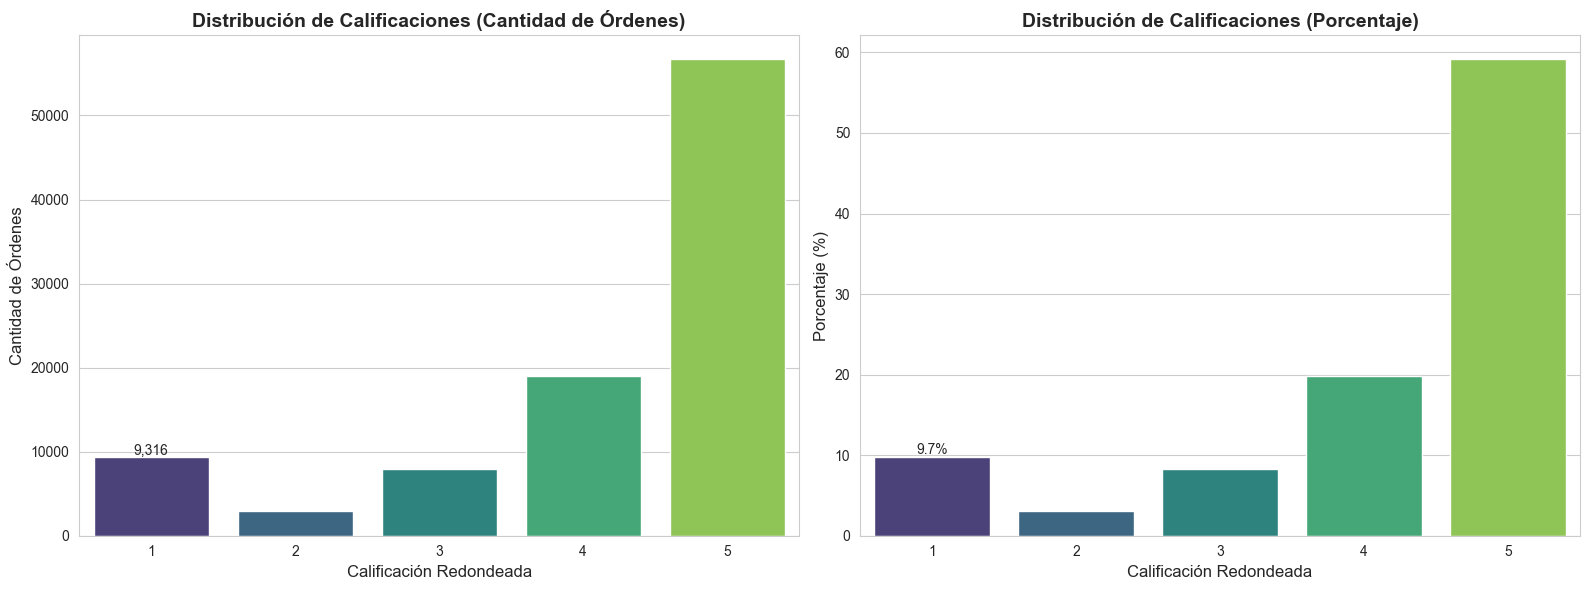

In [14]:
# Visualizar distribución de calificaciones
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de barras con distribución de calificaciones
sns.barplot(data=review_score_distribution, x='review_score_rounded', y='orders', ax=axes[0], palette='viridis')
axes[0].set_title('Distribución de Calificaciones (Cantidad de Órdenes)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Calificación Redondeada', fontsize=12)
axes[0].set_ylabel('Cantidad de Órdenes', fontsize=12)
axes[0].bar_label(axes[0].containers[0], fmt='{:,.0f}')

# Gráfico de porcentaje por calificación
sns.barplot(data=review_score_distribution, x='review_score_rounded', y='percentage', ax=axes[1], palette='viridis')
axes[1].set_title('Distribución de Calificaciones (Porcentaje)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Calificación Redondeada', fontsize=12)
axes[1].set_ylabel('Porcentaje (%)', fontsize=12)
axes[1].bar_label(axes[1].containers[0], fmt='{:,.1f}%')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'review_score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Satisfacción por estado de la orden

In [15]:
# Agrupar por order_status
satisfaction_by_order_status = satisfaction_base.groupby('order_status').agg(
    orders_with_review=('order_id', 'count'),
    avg_review_score=('review_score_avg', 'mean'),
    bad_review_rate=('bad_review', 'mean'),
    good_review_rate=('good_review', 'mean')
).reset_index()

if 'has_review_comment' in satisfaction_base.columns:
    satisfaction_by_order_status['comment_rate'] = satisfaction_base.groupby('order_status')['has_review_comment'].mean().values * 100
else:
    satisfaction_by_order_status['comment_rate'] = 0

satisfaction_by_order_status['bad_review_rate'] = satisfaction_by_order_status['bad_review_rate'] * 100
satisfaction_by_order_status['good_review_rate'] = satisfaction_by_order_status['good_review_rate'] * 100

print("Satisfacción por estado de la orden:")
print(satisfaction_by_order_status)

# Guardar
satisfaction_by_order_status.to_csv(REPORTS_DIR / 'satisfaction_by_order_status.csv', index=False)
print(f"\nGuardado: {REPORTS_DIR / 'satisfaction_by_order_status.csv'}")

Satisfacción por estado de la orden:
  order_status  orders_with_review  avg_review_score  bad_review_rate  good_review_rate  comment_rate
0     canceled                   6          2.000000        66.666667         16.666667    100.000000
1    delivered               95824          4.156158        12.769244         78.914468     40.654742

Guardado: C:\Users\Samuel Vergara\Desktop\Apps\marketpulse-olist-commerce-intelligence\reports\satisfaction_by_order_status.csv


C:\Users\Samuel Vergara\AppData\Local\Temp\ipykernel_3920\1394330298.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=satisfaction_by_order_status, x='order_status', y='avg_review_score', ax=axes[0], palette='viridis')
C:\Users\Samuel Vergara\AppData\Local\Temp\ipykernel_3920\1394330298.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=satisfaction_by_order_status, x='order_status', y='bad_review_rate', ax=axes[1], palette='Reds_r')


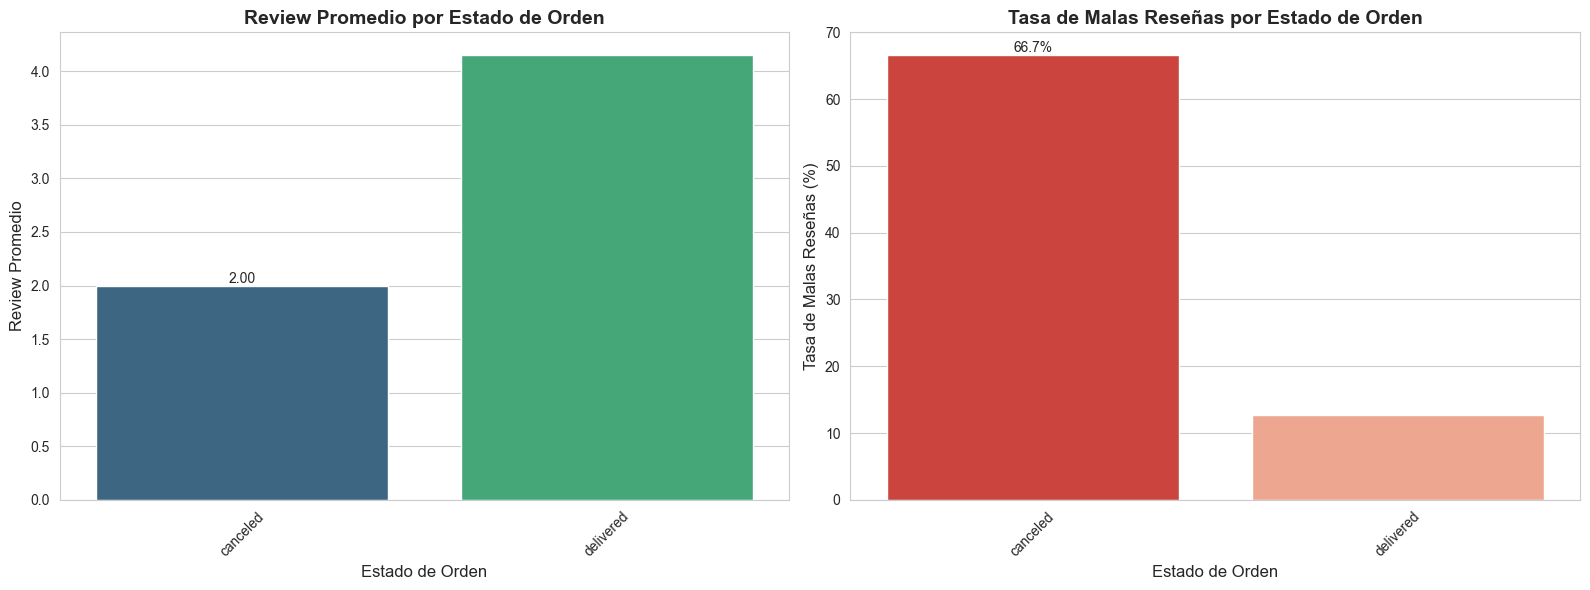

In [16]:
# Visualizar satisfacción por estado de orden
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Review promedio por estado de orden
sns.barplot(data=satisfaction_by_order_status, x='order_status', y='avg_review_score', ax=axes[0], palette='viridis')
axes[0].set_title('Review Promedio por Estado de Orden', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Estado de Orden', fontsize=12)
axes[0].set_ylabel('Review Promedio', fontsize=12)
axes[0].bar_label(axes[0].containers[0], fmt='{:.2f}')
axes[0].tick_params(axis='x', rotation=45)

# Bad review rate por estado de orden
sns.barplot(data=satisfaction_by_order_status, x='order_status', y='bad_review_rate', ax=axes[1], palette='Reds_r')
axes[1].set_title('Tasa de Malas Reseñas por Estado de Orden', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Estado de Orden', fontsize=12)
axes[1].set_ylabel('Tasa de Malas Reseñas (%)', fontsize=12)
axes[1].bar_label(axes[1].containers[0], fmt='{:.1f}%')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'satisfaction_by_order_status.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Satisfacción mensual

In [17]:
# Agrupar por purchase_year_month
monthly_satisfaction_metrics = satisfaction_base.groupby('purchase_year_month').agg(
    orders_with_review=('order_id', 'count'),
    avg_review_score=('review_score_avg', 'mean'),
    bad_review_rate=('bad_review', 'mean'),
    good_review_rate=('good_review', 'mean')
).reset_index()

if 'has_review_comment' in satisfaction_base.columns:
    monthly_satisfaction_metrics['comment_rate'] = satisfaction_base.groupby('purchase_year_month')['has_review_comment'].mean().values * 100
else:
    monthly_satisfaction_metrics['comment_rate'] = 0

monthly_satisfaction_metrics['bad_review_rate'] = monthly_satisfaction_metrics['bad_review_rate'] * 100
monthly_satisfaction_metrics['good_review_rate'] = monthly_satisfaction_metrics['good_review_rate'] * 100

print("Satisfacción mensual:")
print(monthly_satisfaction_metrics.head(15))

# Guardar
monthly_satisfaction_metrics.to_csv(REPORTS_DIR / 'monthly_satisfaction_metrics.csv', index=False)
print(f"\nGuardado: {REPORTS_DIR / 'monthly_satisfaction_metrics.csv'}")

Satisfacción mensual:
   purchase_year_month  orders_with_review  avg_review_score  bad_review_rate  good_review_rate  comment_rate
0              2016-09                   1          1.000000       100.000000          0.000000    100.000000
1              2016-10                 267          3.970037        17.602996         74.531835     70.411985
2              2016-12                   1          5.000000         0.000000        100.000000    100.000000
3              2017-01                 741          4.199055        12.010796         79.757085     44.939271
4              2017-02                1643          4.202678        11.077298         79.306147     44.065733
5              2017-03                2527          4.187376        11.238623         79.699248     42.144836
6              2017-04                2290          4.137555        12.794760         78.165939     41.135371
7              2017-05                3517          4.238271        10.008530         80.949673   

C:\Users\Samuel Vergara\AppData\Local\Temp\ipykernel_3920\1422369391.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_satisfaction_metrics, x='purchase_year_month', y='orders_with_review', ax=axes[2], palette='viridis')


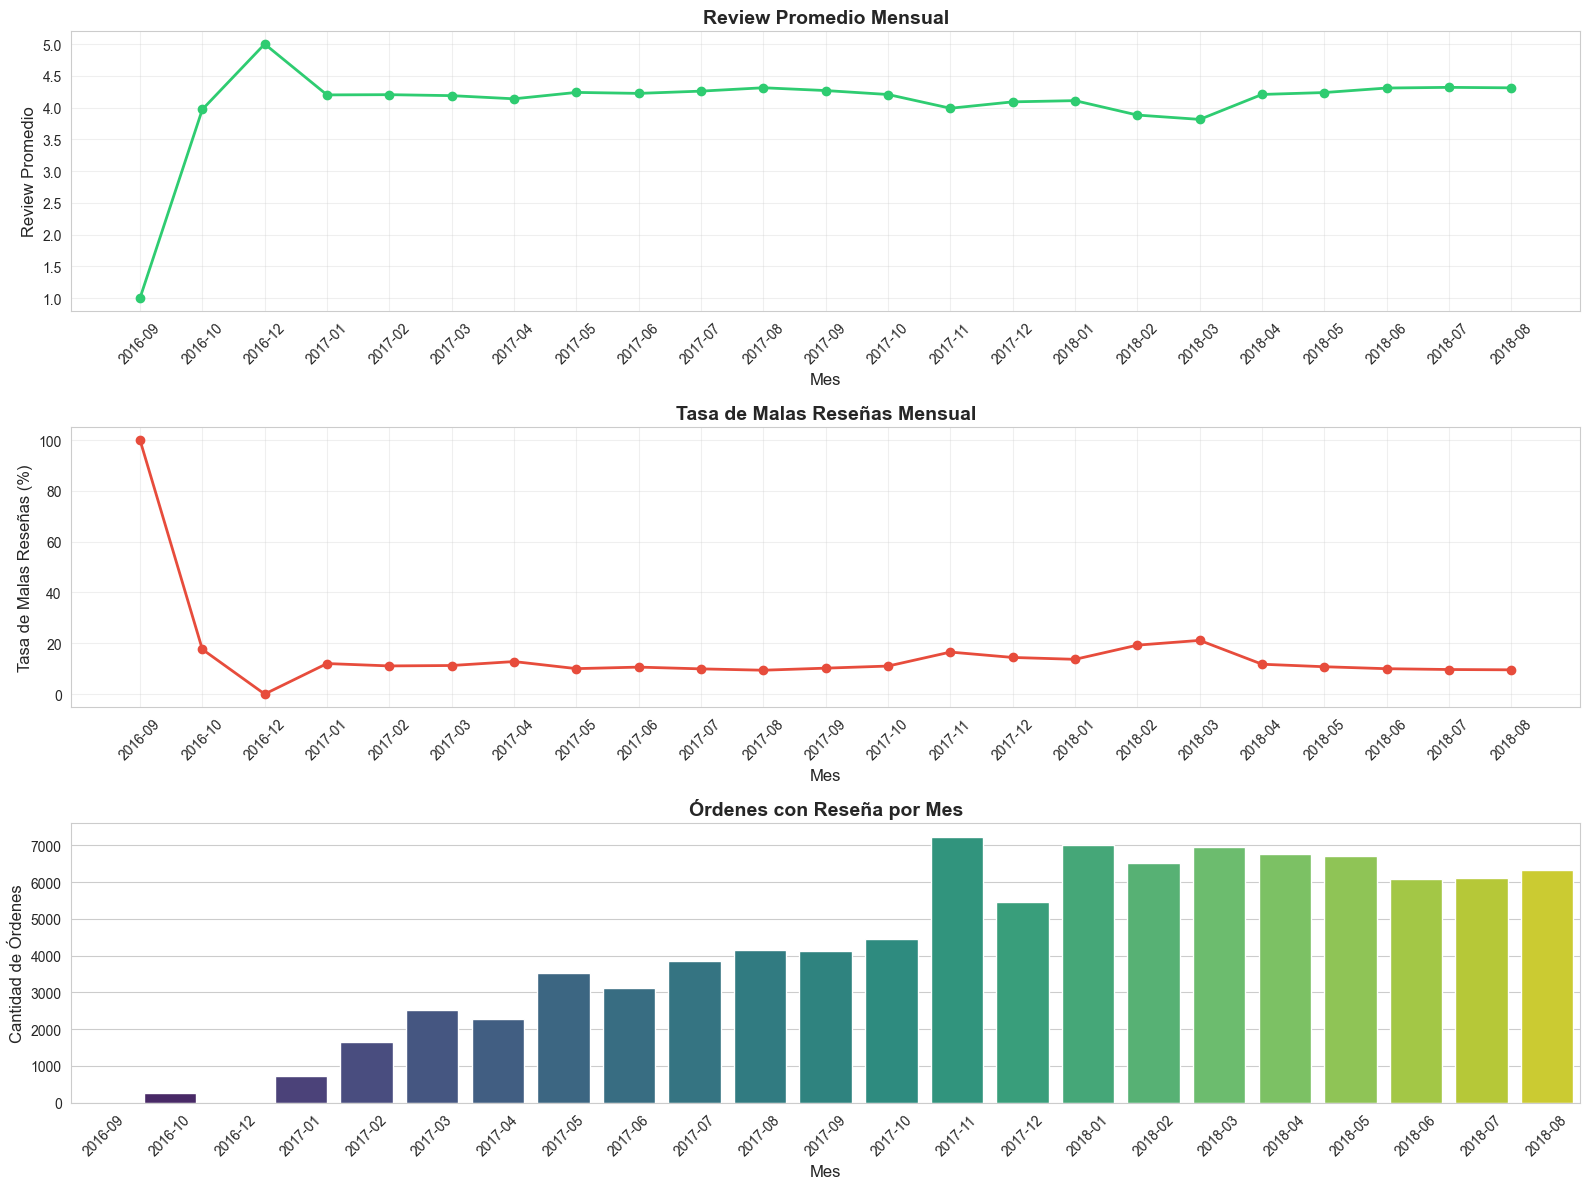

In [18]:
# Visualizar satisfacción mensual
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Línea de review promedio mensual
axes[0].plot(monthly_satisfaction_metrics['purchase_year_month'], monthly_satisfaction_metrics['avg_review_score'], 
             marker='o', linewidth=2, markersize=6, color='#2ecc71')
axes[0].set_title('Review Promedio Mensual', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Mes', fontsize=12)
axes[0].set_ylabel('Review Promedio', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# Línea de bad_review_rate mensual
axes[1].plot(monthly_satisfaction_metrics['purchase_year_month'], monthly_satisfaction_metrics['bad_review_rate'], 
             marker='o', linewidth=2, markersize=6, color='#e74c3c')
axes[1].set_title('Tasa de Malas Reseñas Mensual', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Mes', fontsize=12)
axes[1].set_ylabel('Tasa de Malas Reseñas (%)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

# Barras de órdenes con reseña por mes
sns.barplot(data=monthly_satisfaction_metrics, x='purchase_year_month', y='orders_with_review', ax=axes[2], palette='viridis')
axes[2].set_title('Órdenes con Reseña por Mes', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Mes', fontsize=12)
axes[2].set_ylabel('Cantidad de Órdenes', fontsize=12)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'monthly_satisfaction_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

**Nota:** Septiembre y octubre de 2018 pueden estar incompletos y deben analizarse con cuidado, ya que corresponden a los últimos meses del periodo de datos.

## 10. Satisfacción por categoría

In [19]:
# Agrupar por main_category
satisfaction_by_category = satisfaction_base.groupby('main_category').agg(
    orders_with_review=('order_id', 'count'),
    avg_review_score=('review_score_avg', 'mean'),
    bad_review_rate=('bad_review', 'mean'),
    good_review_rate=('good_review', 'mean'),
    avg_delivery_time_days=('delivery_time_days', 'mean'),
    late_delivery_rate=('is_late', 'mean'),
    avg_freight_value=('total_freight', 'mean'),
    avg_freight_ratio=('freight_ratio', 'mean')
).reset_index()

if 'has_review_comment' in satisfaction_base.columns:
    satisfaction_by_category['comment_rate'] = satisfaction_base.groupby('main_category')['has_review_comment'].mean().values * 100
else:
    satisfaction_by_category['comment_rate'] = 0

satisfaction_by_category['bad_review_rate'] = satisfaction_by_category['bad_review_rate'] * 100
satisfaction_by_category['good_review_rate'] = satisfaction_by_category['good_review_rate'] * 100
satisfaction_by_category['late_delivery_rate'] = satisfaction_by_category['late_delivery_rate'] * 100

# Filtrar categorías con mínimo 100 órdenes con reseña para visualización
satisfaction_by_category_filtered = satisfaction_by_category[
    satisfaction_by_category['orders_with_review'] >= 100
].sort_values('orders_with_review', ascending=False)

print(f"Categorías con mínimo 100 órdenes con reseña: {len(satisfaction_by_category_filtered)}")
print(satisfaction_by_category_filtered.head(15))

# Guardar tabla completa
satisfaction_by_category.to_csv(REPORTS_DIR / 'satisfaction_by_category.csv', index=False)
print(f"\nGuardado: {REPORTS_DIR / 'satisfaction_by_category.csv'}")

Categorías con mínimo 100 órdenes con reseña: 52
            main_category  orders_with_review  avg_review_score  bad_review_rate  good_review_rate  avg_delivery_time_days  late_delivery_rate  avg_freight_value  avg_freight_ratio  comment_rate
7          bed_bath_table                9144          4.003390        15.791776         74.048556               12.951876            8.617673          22.134420           0.271169     45.778653
43          health_beauty                8577          4.232230        11.355952         80.949050               12.057813            8.837589          20.774372           0.279178     37.682173
65         sports_leisure                7434          4.237557        11.138015         81.638418               12.238386            7.707829          21.755444           0.281751     37.691687
15  computers_accessories                6488          4.082768        14.457460         77.250308               13.141787            7.598644          22.210584          

C:\Users\Samuel Vergara\AppData\Local\Temp\ipykernel_3920\45988270.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_15_best_categories, y='main_category', x='avg_review_score', palette='Greens_r')


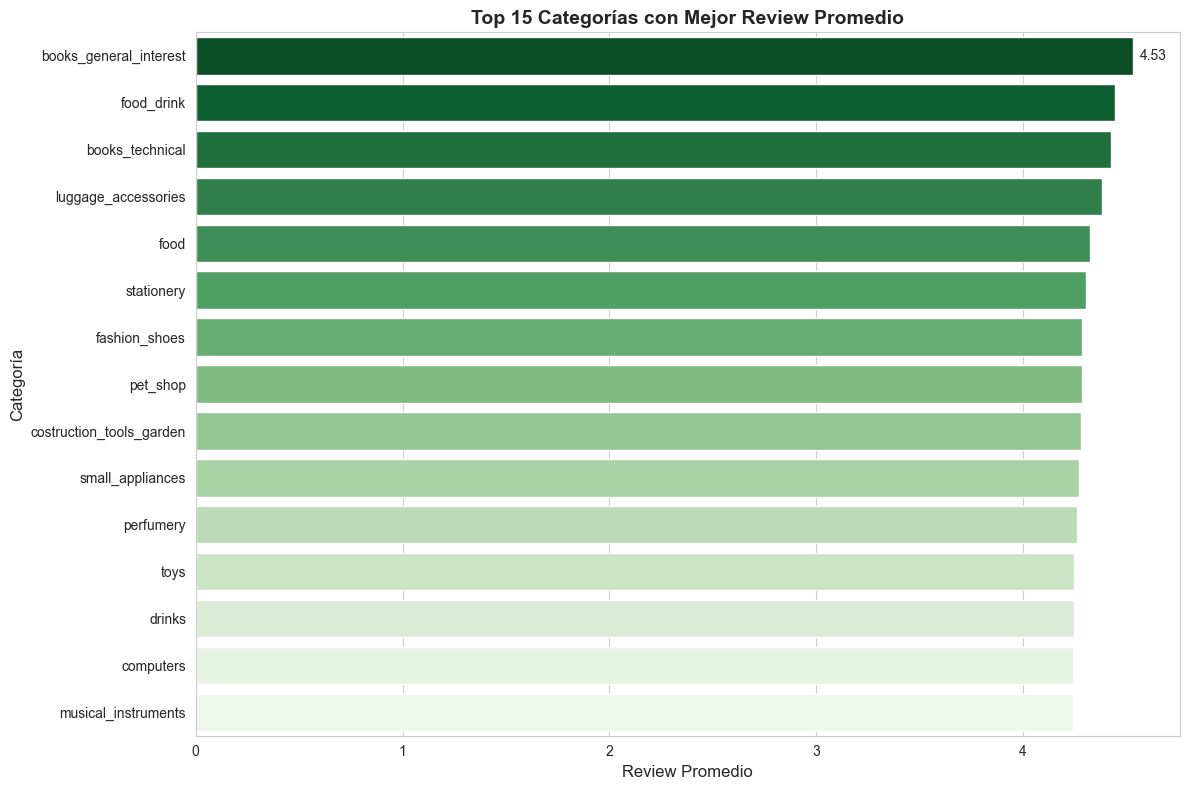

In [20]:
# Top 15 categorías con mejor review promedio
top_15_best_categories = satisfaction_by_category_filtered.nlargest(15, 'avg_review_score')

plt.figure(figsize=(12, 8))
sns.barplot(data=top_15_best_categories, y='main_category', x='avg_review_score', palette='Greens_r')
plt.title('Top 15 Categorías con Mejor Review Promedio', fontsize=14, fontweight='bold')
plt.xlabel('Review Promedio', fontsize=12)
plt.ylabel('Categoría', fontsize=12)
plt.bar_label(plt.gca().containers[0], fmt='{:.2f}', padding=5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top_15_best_categories.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Samuel Vergara\AppData\Local\Temp\ipykernel_3920\2139330188.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_15_worst_categories, y='main_category', x='avg_review_score', palette='Reds_r')


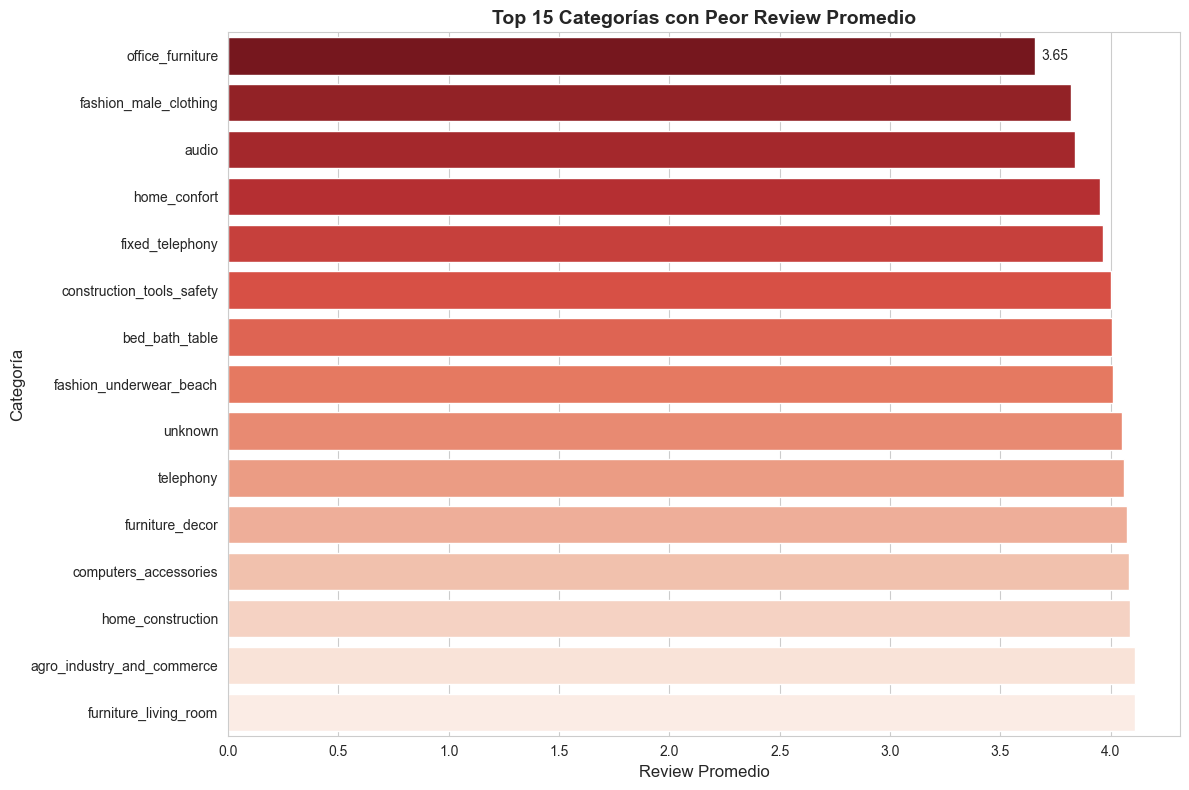

In [21]:
# Top 15 categorías con peor review promedio
top_15_worst_categories = satisfaction_by_category_filtered.nsmallest(15, 'avg_review_score')

plt.figure(figsize=(12, 8))
sns.barplot(data=top_15_worst_categories, y='main_category', x='avg_review_score', palette='Reds_r')
plt.title('Top 15 Categorías con Peor Review Promedio', fontsize=14, fontweight='bold')
plt.xlabel('Review Promedio', fontsize=12)
plt.ylabel('Categoría', fontsize=12)
plt.bar_label(plt.gca().containers[0], fmt='{:.2f}', padding=5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top_15_worst_categories.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Samuel Vergara\AppData\Local\Temp\ipykernel_3920\1889186204.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_15_bad_review_categories, y='main_category', x='bad_review_rate', palette='Reds')


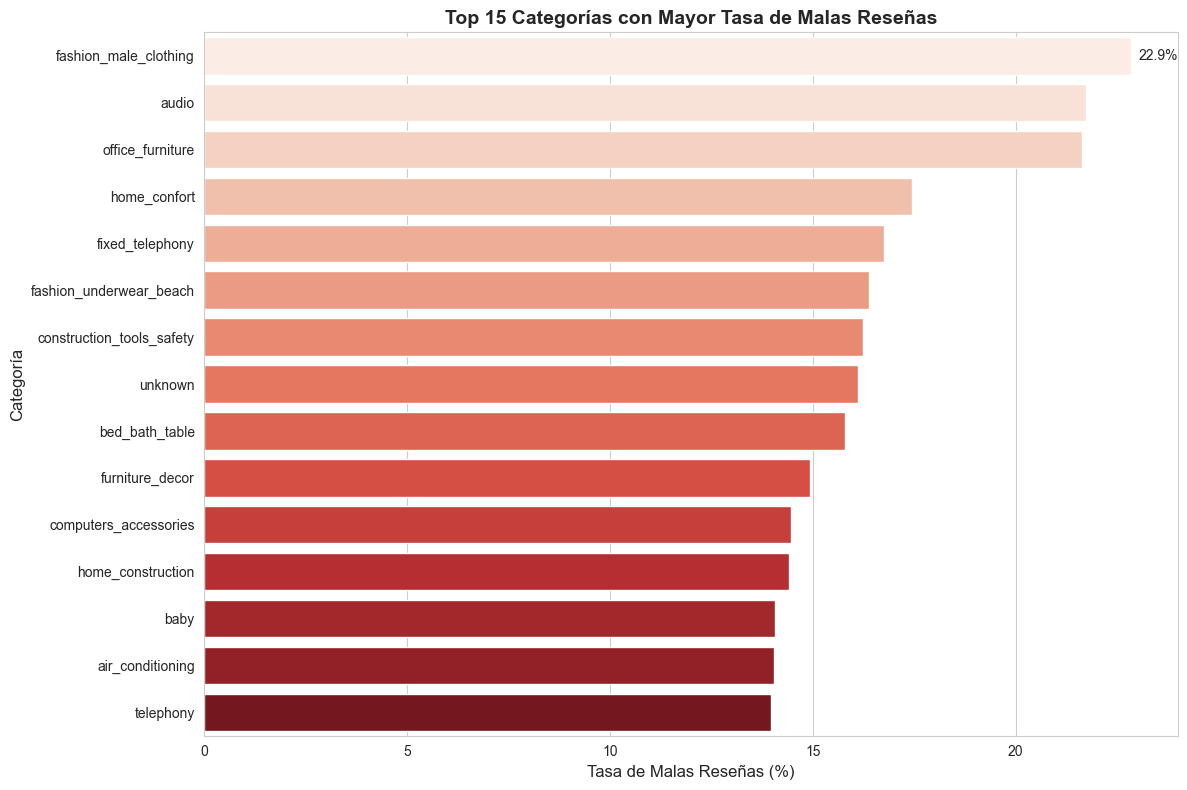

In [22]:
# Top 15 categorías con mayor bad_review_rate
top_15_bad_review_categories = satisfaction_by_category_filtered.nlargest(15, 'bad_review_rate')

plt.figure(figsize=(12, 8))
sns.barplot(data=top_15_bad_review_categories, y='main_category', x='bad_review_rate', palette='Reds')
plt.title('Top 15 Categorías con Mayor Tasa de Malas Reseñas', fontsize=14, fontweight='bold')
plt.xlabel('Tasa de Malas Reseñas (%)', fontsize=12)
plt.ylabel('Categoría', fontsize=12)
plt.bar_label(plt.gca().containers[0], fmt='{:.1f}%', padding=5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top_15_bad_review_categories.png', dpi=300, bbox_inches='tight')
plt.show()

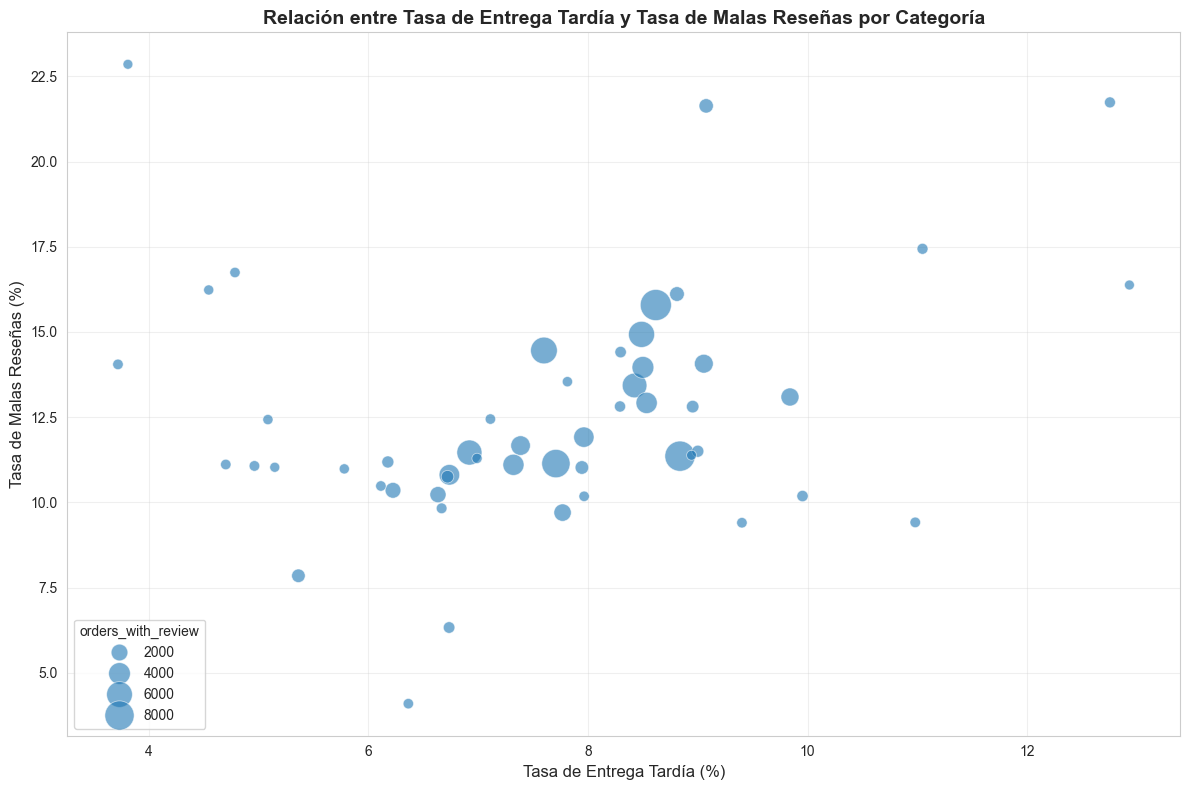

In [23]:
# Relación entre late_delivery_rate y bad_review_rate por categoría
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=satisfaction_by_category_filtered, x='late_delivery_rate', y='bad_review_rate', 
                size='orders_with_review', sizes=(50, 500), alpha=0.6, ax=ax)
ax.set_title('Relación entre Tasa de Entrega Tardía y Tasa de Malas Reseñas por Categoría', fontsize=14, fontweight='bold')
ax.set_xlabel('Tasa de Entrega Tardía (%)', fontsize=12)
ax.set_ylabel('Tasa de Malas Reseñas (%)', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'late_delivery_vs_bad_review_by_category.png', dpi=300, bbox_inches='tight')
plt.show()

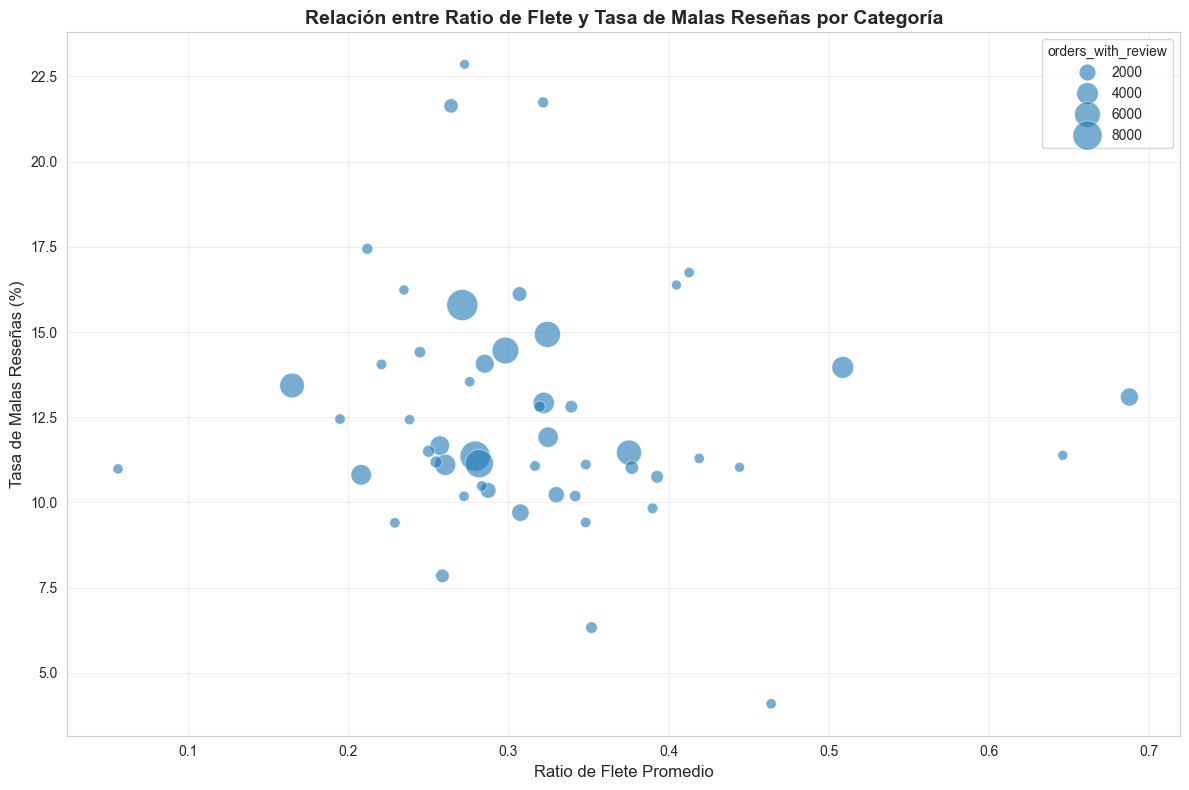

In [24]:
# Relación entre avg_freight_ratio y bad_review_rate por categoría
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=satisfaction_by_category_filtered, x='avg_freight_ratio', y='bad_review_rate', 
                size='orders_with_review', sizes=(50, 500), alpha=0.6, ax=ax)
ax.set_title('Relación entre Ratio de Flete y Tasa de Malas Reseñas por Categoría', fontsize=14, fontweight='bold')
ax.set_xlabel('Ratio de Flete Promedio', fontsize=12)
ax.set_ylabel('Tasa de Malas Reseñas (%)', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'freight_ratio_vs_bad_review_by_category.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Satisfacción por estado del cliente

In [25]:
# Agrupar por customer_state
satisfaction_by_state = satisfaction_base.groupby('customer_state').agg(
    orders_with_review=('order_id', 'count'),
    avg_review_score=('review_score_avg', 'mean'),
    bad_review_rate=('bad_review', 'mean'),
    good_review_rate=('good_review', 'mean'),
    avg_delivery_time_days=('delivery_time_days', 'mean'),
    late_delivery_rate=('is_late', 'mean'),
    avg_freight_value=('total_freight', 'mean'),
    avg_freight_ratio=('freight_ratio', 'mean')
).reset_index()

if 'has_review_comment' in satisfaction_base.columns:
    satisfaction_by_state['comment_rate'] = satisfaction_base.groupby('customer_state')['has_review_comment'].mean().values * 100
else:
    satisfaction_by_state['comment_rate'] = 0

satisfaction_by_state['bad_review_rate'] = satisfaction_by_state['bad_review_rate'] * 100
satisfaction_by_state['good_review_rate'] = satisfaction_by_state['good_review_rate'] * 100
satisfaction_by_state['late_delivery_rate'] = satisfaction_by_state['late_delivery_rate'] * 100

# Filtrar estados con mínimo 100 órdenes con reseña para visualización
satisfaction_by_state_filtered = satisfaction_by_state[
    satisfaction_by_state['orders_with_review'] >= 100
].sort_values('orders_with_review', ascending=False)

print(f"Estados con mínimo 100 órdenes con reseña: {len(satisfaction_by_state_filtered)}")
print(satisfaction_by_state_filtered.head(15))

# Guardar tabla completa
satisfaction_by_state.to_csv(REPORTS_DIR / 'satisfaction_by_customer_state.csv', index=False)
print(f"\nGuardado: {REPORTS_DIR / 'satisfaction_by_customer_state.csv'}")

Estados con mínimo 100 órdenes con reseña: 24
   customer_state  orders_with_review  avg_review_score  bad_review_rate  good_review_rate  avg_delivery_time_days  late_delivery_rate  avg_freight_value  avg_freight_ratio  comment_rate
25             SP               40267          4.246538        10.641468         81.399161                8.747150            5.833561          17.331024           0.251584     39.054312
18             RJ               12214          3.964412        18.315048         73.374816               15.242510           13.288030          23.913823           0.315663     44.047814
10             MG               11286          4.192362        11.704767         79.860004               11.985587            5.520113          23.428270           0.315987     40.129364
22             RS                5326          4.185599        11.885092         79.834773               15.280345            7.097259          24.806833           0.339068     36.518964
17             PR  

C:\Users\Samuel Vergara\AppData\Local\Temp\ipykernel_3920\4184388209.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_best_states, x='customer_state', y='avg_review_score', palette='Greens_r')


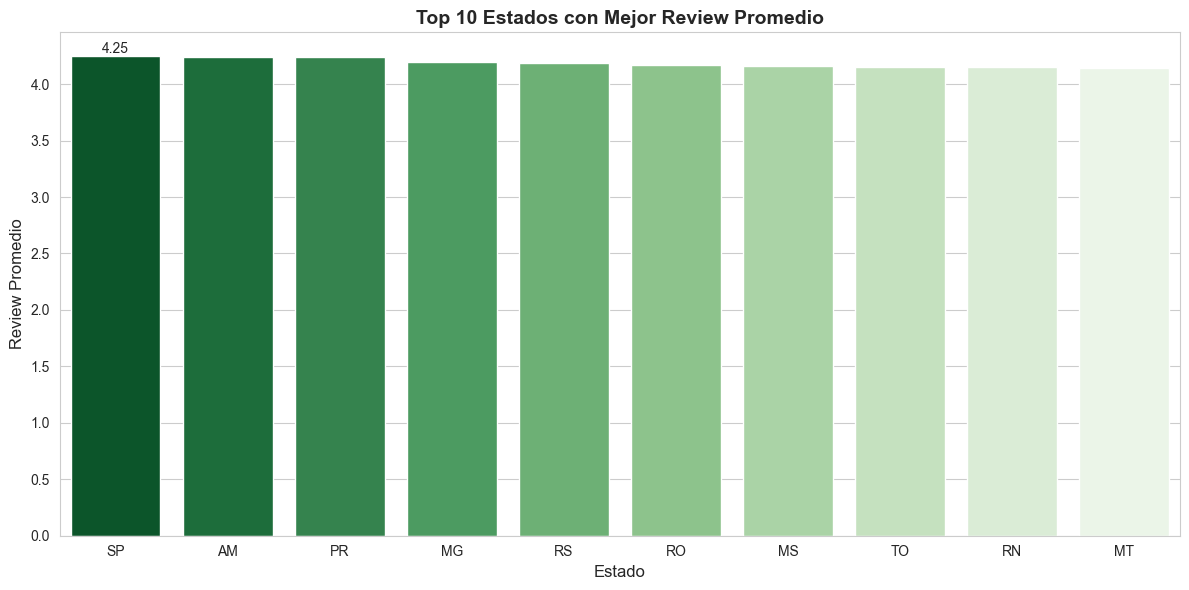

In [26]:
# Top 10 estados con mejor review promedio
top_10_best_states = satisfaction_by_state_filtered.nlargest(10, 'avg_review_score')

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_best_states, x='customer_state', y='avg_review_score', palette='Greens_r')
plt.title('Top 10 Estados con Mejor Review Promedio', fontsize=14, fontweight='bold')
plt.xlabel('Estado', fontsize=12)
plt.ylabel('Review Promedio', fontsize=12)
plt.bar_label(plt.gca().containers[0], fmt='{:.2f}')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top_10_best_states.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Samuel Vergara\AppData\Local\Temp\ipykernel_3920\1192583020.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_worst_states, x='customer_state', y='avg_review_score', palette='Reds_r')


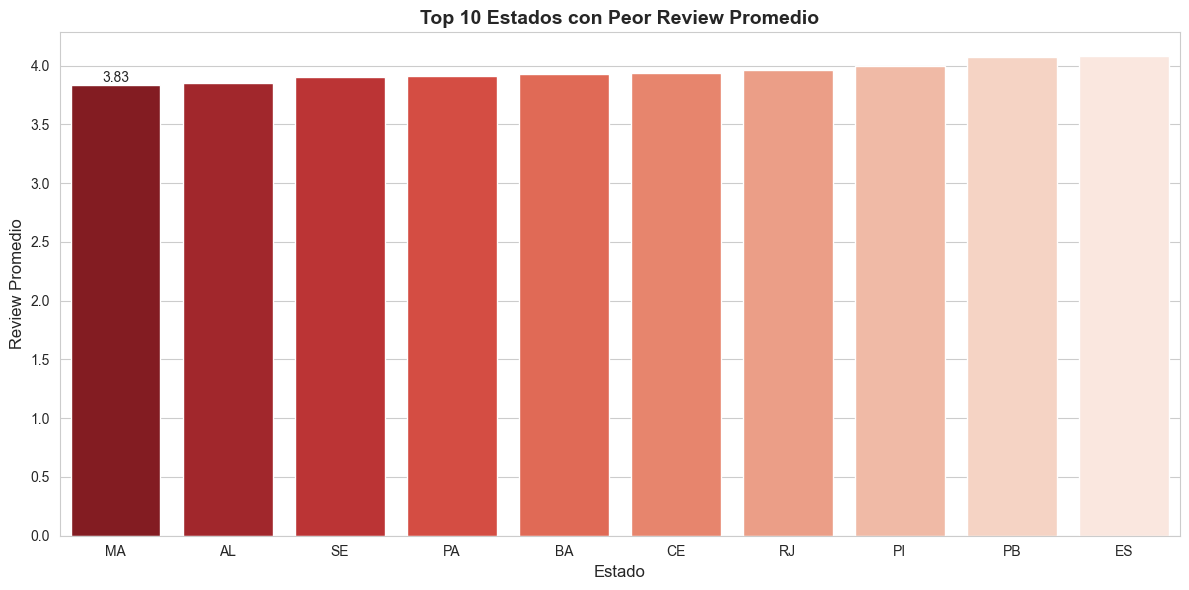

In [27]:
# Top 10 estados con peor review promedio
top_10_worst_states = satisfaction_by_state_filtered.nsmallest(10, 'avg_review_score')

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_worst_states, x='customer_state', y='avg_review_score', palette='Reds_r')
plt.title('Top 10 Estados con Peor Review Promedio', fontsize=14, fontweight='bold')
plt.xlabel('Estado', fontsize=12)
plt.ylabel('Review Promedio', fontsize=12)
plt.bar_label(plt.gca().containers[0], fmt='{:.2f}')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top_10_worst_states.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Samuel Vergara\AppData\Local\Temp\ipykernel_3920\3457864162.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_bad_review_states, x='customer_state', y='bad_review_rate', palette='Reds')


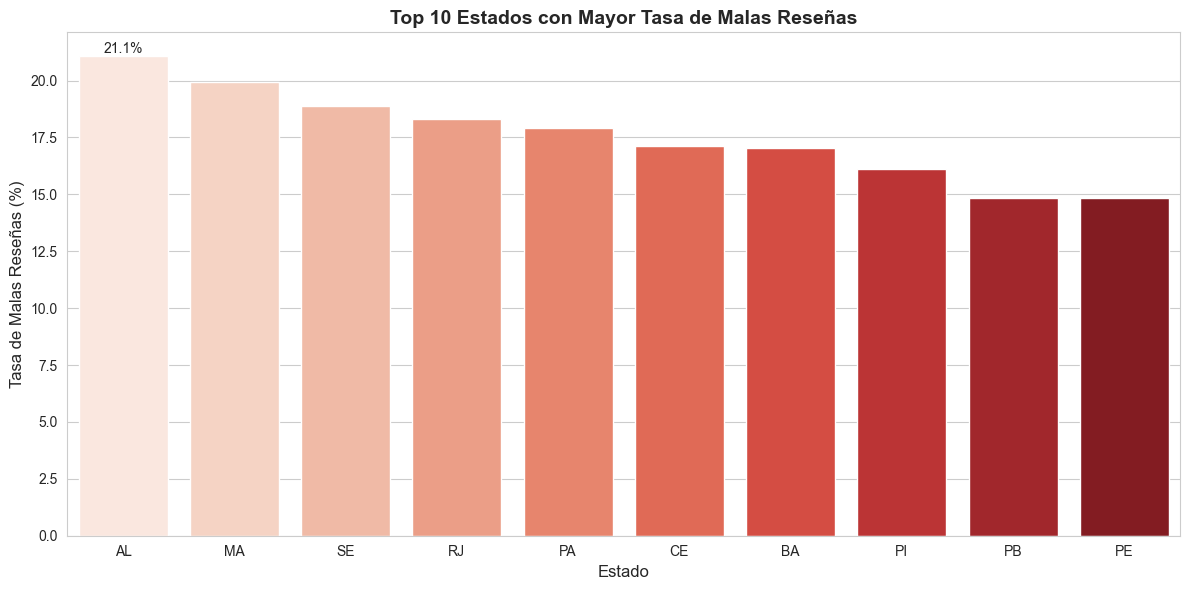

In [28]:
# Top 10 estados con mayor bad_review_rate
top_10_bad_review_states = satisfaction_by_state_filtered.nlargest(10, 'bad_review_rate')

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_bad_review_states, x='customer_state', y='bad_review_rate', palette='Reds')
plt.title('Top 10 Estados con Mayor Tasa de Malas Reseñas', fontsize=14, fontweight='bold')
plt.xlabel('Estado', fontsize=12)
plt.ylabel('Tasa de Malas Reseñas (%)', fontsize=12)
plt.bar_label(plt.gca().containers[0], fmt='{:.1f}%')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top_10_bad_review_states.png', dpi=300, bbox_inches='tight')
plt.show()

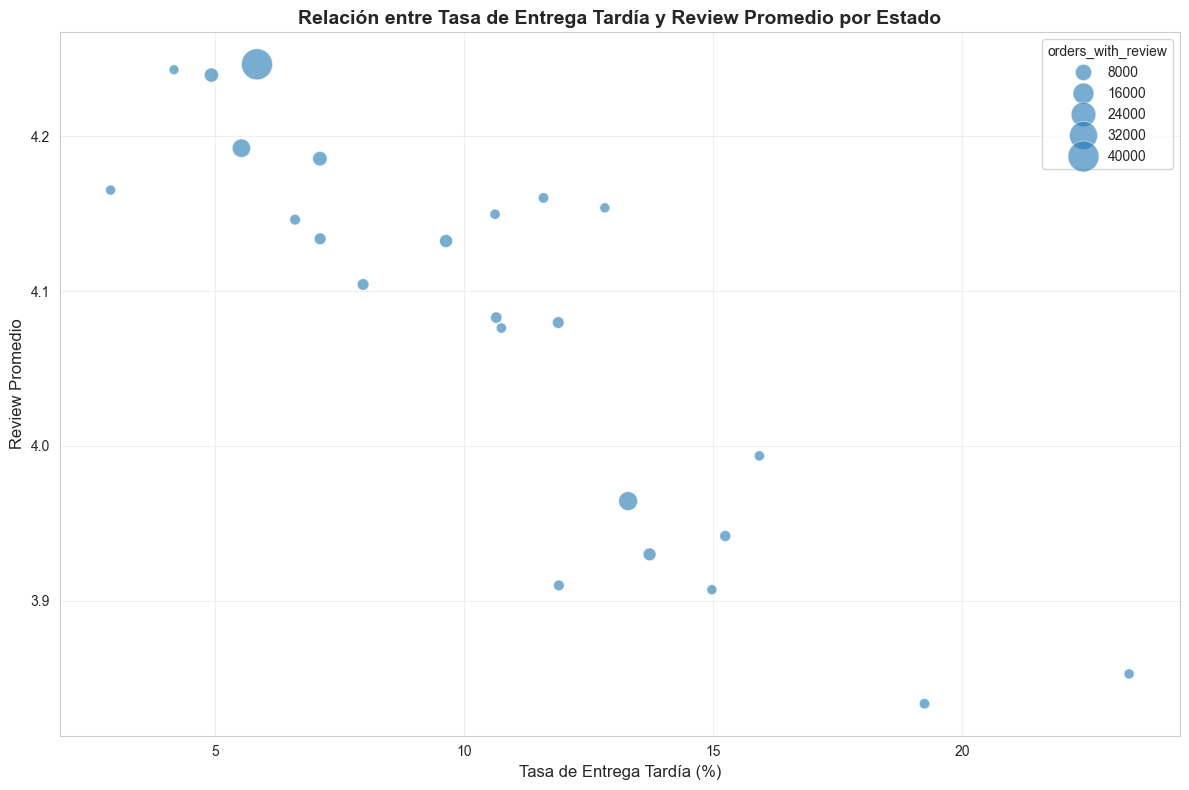

In [29]:
# Relación entre late_delivery_rate y avg_review_score por estado
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=satisfaction_by_state_filtered, x='late_delivery_rate', y='avg_review_score', 
                size='orders_with_review', sizes=(50, 500), alpha=0.6, ax=ax)
ax.set_title('Relación entre Tasa de Entrega Tardía y Review Promedio por Estado', fontsize=14, fontweight='bold')
ax.set_xlabel('Tasa de Entrega Tardía (%)', fontsize=12)
ax.set_ylabel('Review Promedio', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'late_delivery_vs_review_by_state.png', dpi=300, bbox_inches='tight')
plt.show()

## 12. Impacto de la logística en la satisfacción

In [31]:
# Usar delivered_satisfaction_base para análisis logístico
delivered_satisfaction_base = delivered_satisfaction_base.copy()

# Revisar columnas disponibles
print("Columnas disponibles:")
print(delivered_satisfaction_base.columns.tolist())

# Crear bad_review si no existe
# Mala reseña: review_score <= 2
if 'bad_review' not in delivered_satisfaction_base.columns:
    delivered_satisfaction_base['bad_review'] = (
        delivered_satisfaction_base['review_score_avg'] <= 2
    ).astype(int)

# Crear good_review si no existe
# Buena reseña: review_score >= 4
if 'good_review' not in delivered_satisfaction_base.columns:
    delivered_satisfaction_base['good_review'] = (
        delivered_satisfaction_base['review_score_avg'] >= 4
    ).astype(int)

# Asegurar que is_late esté en formato 0/1
delivered_satisfaction_base['is_late'] = delivered_satisfaction_base['is_late'].astype(int)

# Comparar satisfacción según is_late
satisfaction_by_late = (
    delivered_satisfaction_base
    .groupby('is_late')
    .agg(
        orders_with_review=('order_id', 'count'),
        avg_review_score=('review_score_avg', 'mean'),
        bad_review_rate=('bad_review', 'mean'),
        good_review_rate=('good_review', 'mean')
    )
    .reset_index()
)

# Convertir tasas a porcentaje
satisfaction_by_late['bad_review_rate'] = satisfaction_by_late['bad_review_rate'] * 100
satisfaction_by_late['good_review_rate'] = satisfaction_by_late['good_review_rate'] * 100

# Etiquetas legibles
satisfaction_by_late['is_late'] = satisfaction_by_late['is_late'].map({
    0: 'No tardía',
    1: 'Tardía'
})

print("Satisfacción según entrega tardía:")
display(satisfaction_by_late)

Columnas disponibles:
['order_id', 'customer_id', 'customer_unique_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'items_count', 'products_count', 'sellers_count', 'total_price', 'total_freight', 'payment_total', 'avg_item_price', 'max_item_price', 'min_item_price', 'main_category', 'main_payment_type', 'payment_count', 'max_installments', 'avg_installments', 'payment_types_count', 'review_score_avg', 'review_score_min', 'review_score_max', 'reviews_count', 'has_review_comment', 'bad_review', 'purchase_year', 'purchase_month', 'purchase_year_month', 'purchase_dayofweek', 'purchase_hour', 'is_delivered', 'is_canceled', 'is_unavailable', 'approval_time_days', 'carrier_handling_time_days', 'delivery_time_days', 'estimated_delivery_time_days', 'delivery_delay_days', 'is_late', 'freight_ratio', 'average_ticket

,is_late,orders_with_review,avg_review_score,bad_review_rate,good_review_rate
0,No tardía,88168,4.294151,9.995560,82.764722
1,Tardía,7662,2.566562,60.966981,34.560167


In [32]:
# Crear variable delay_group
def categorize_delay(days):
    if pd.isna(days):
        return 'Sin dato'
    elif days < 0:
        return 'Anticipada'
    elif days == 0:
        return 'A tiempo'
    elif 1 <= days <= 3:
        return 'Retraso leve (1-3 días)'
    elif 4 <= days <= 7:
        return 'Retraso medio (4-7 días)'
    else:
        return 'Retraso alto (8+ días)'

delivered_satisfaction_base['delay_group'] = delivered_satisfaction_base['delivery_delay_days'].apply(categorize_delay)

# Agrupar por delay_group
satisfaction_by_delay_group = delivered_satisfaction_base.groupby('delay_group').agg(
    orders_with_review=('order_id', 'count'),
    avg_review_score=('review_score_avg', 'mean'),
    bad_review_rate=('bad_review', 'mean'),
    good_review_rate=('good_review', 'mean')
).reset_index()

satisfaction_by_delay_group['bad_review_rate'] = satisfaction_by_delay_group['bad_review_rate'] * 100
satisfaction_by_delay_group['good_review_rate'] = satisfaction_by_delay_group['good_review_rate'] * 100

# Ordenar por delay_group según el orden lógico
delay_order = ['Anticipada', 'A tiempo', 'Retraso leve (1-3 días)', 'Retraso medio (4-7 días)', 'Retraso alto (8+ días)', 'Sin dato']
satisfaction_by_delay_group['delay_group'] = pd.Categorical(satisfaction_by_delay_group['delay_group'], categories=delay_order)
satisfaction_by_delay_group = satisfaction_by_delay_group.sort_values('delay_group')

print("Satisfacción por grupo de retraso:")
print(satisfaction_by_delay_group)

# Guardar
satisfaction_by_delay_group.to_csv(REPORTS_DIR / 'satisfaction_by_delay_group.csv', index=False)
print(f"\nGuardado: {REPORTS_DIR / 'satisfaction_by_delay_group.csv'}")

Satisfacción por grupo de retraso:
                delay_group  orders_with_review  avg_review_score  bad_review_rate  good_review_rate
0                Anticipada               88168          4.294151         9.995560         82.764722
2   Retraso leve (1-3 días)                1356          3.513274        30.060817         59.365782
3  Retraso medio (4-7 días)                1277          2.175020        72.758921         24.510572
1    Retraso alto (8+ días)                5029          2.410718        65.878680         30.423543

Guardado: C:\Users\Samuel Vergara\Desktop\Apps\marketpulse-olist-commerce-intelligence\reports\satisfaction_by_delay_group.csv


C:\Users\Samuel Vergara\AppData\Local\Temp\ipykernel_3920\1696081535.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=satisfaction_by_delay_group, x='delay_group', y='avg_review_score', ax=axes[0], palette='RdYlGn')
C:\Users\Samuel Vergara\AppData\Local\Temp\ipykernel_3920\1696081535.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=satisfaction_by_delay_group, x='delay_group', y='bad_review_rate', ax=axes[1], palette='Reds_r')


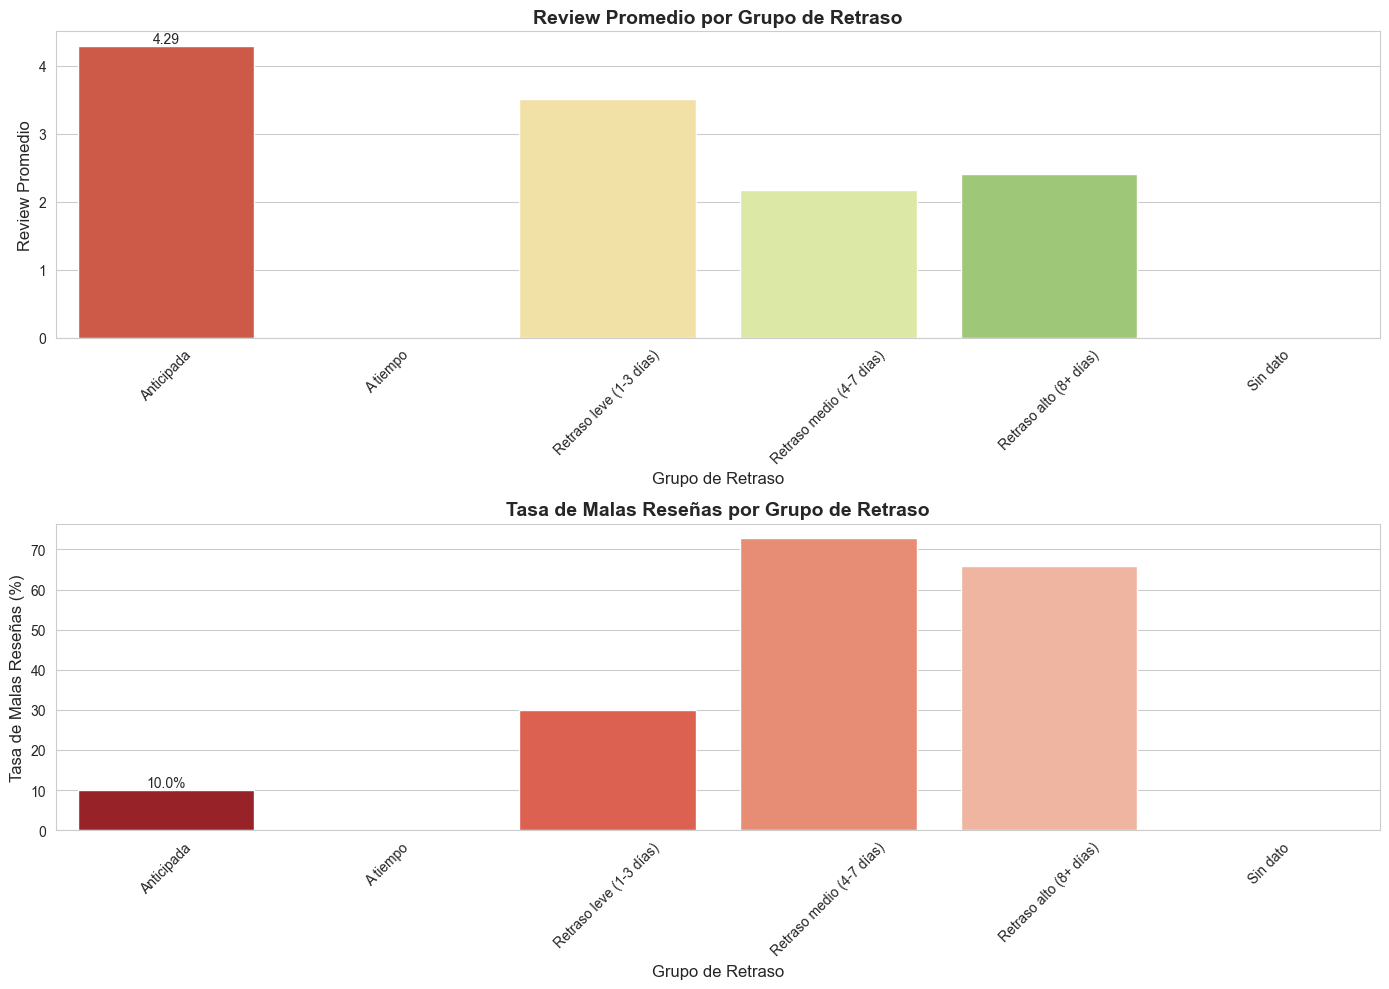

In [33]:
# Visualizar satisfacción por grupo de retraso
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Review promedio por grupo de retraso
sns.barplot(data=satisfaction_by_delay_group, x='delay_group', y='avg_review_score', ax=axes[0], palette='RdYlGn')
axes[0].set_title('Review Promedio por Grupo de Retraso', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Grupo de Retraso', fontsize=12)
axes[0].set_ylabel('Review Promedio', fontsize=12)
axes[0].bar_label(axes[0].containers[0], fmt='{:.2f}')
axes[0].tick_params(axis='x', rotation=45)

# Bad review rate por grupo de retraso
sns.barplot(data=satisfaction_by_delay_group, x='delay_group', y='bad_review_rate', ax=axes[1], palette='Reds_r')
axes[1].set_title('Tasa de Malas Reseñas por Grupo de Retraso', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Grupo de Retraso', fontsize=12)
axes[1].set_ylabel('Tasa de Malas Reseñas (%)', fontsize=12)
axes[1].bar_label(axes[1].containers[0], fmt='{:.1f}%')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'satisfaction_by_delay_group.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Samuel Vergara\AppData\Local\Temp\ipykernel_3920\2641343214.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=delivered_satisfaction_base, x='delay_group', y='review_score_avg',


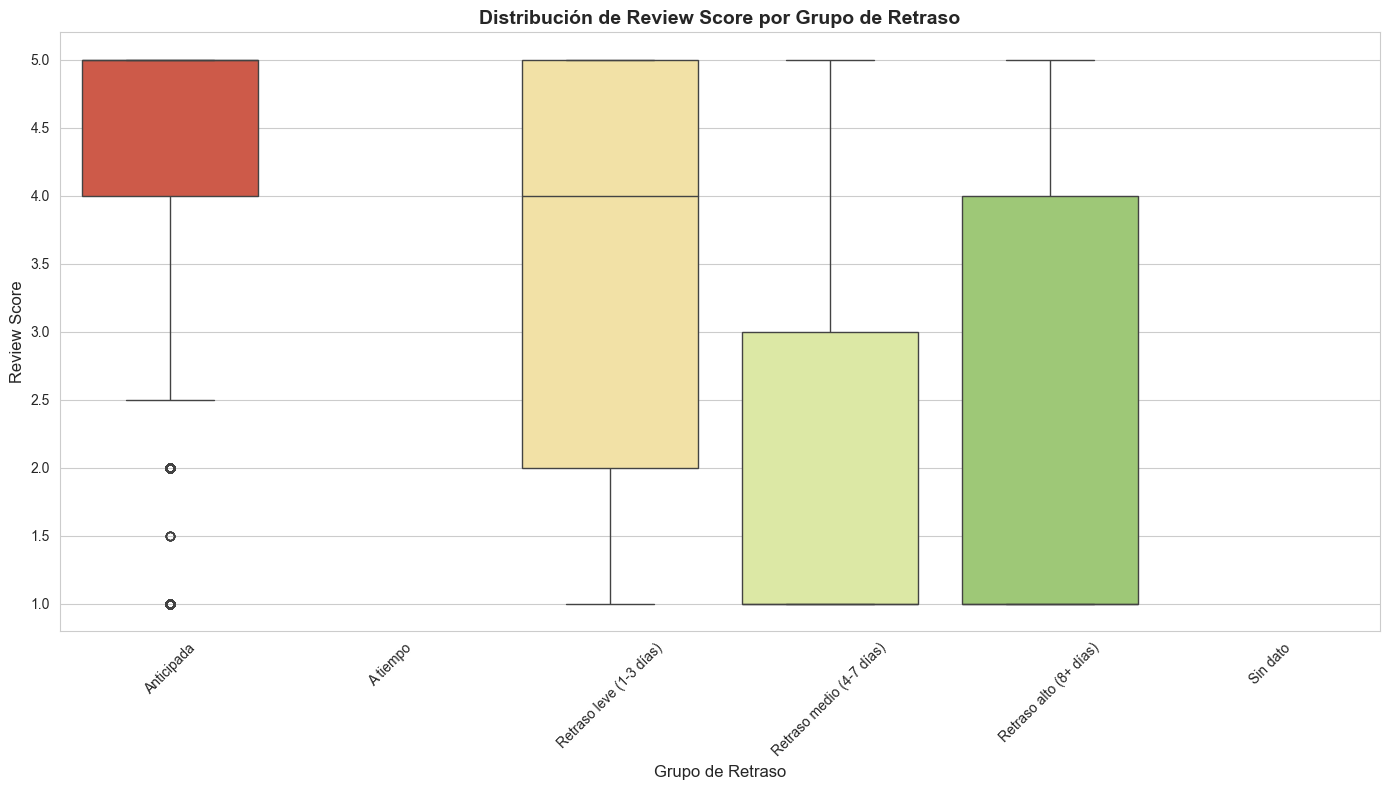

In [34]:
# Boxplot de review_score_avg por delay_group
plt.figure(figsize=(14, 8))
sns.boxplot(data=delivered_satisfaction_base, x='delay_group', y='review_score_avg', 
            order=delay_order, palette='RdYlGn')
plt.title('Distribución de Review Score por Grupo de Retraso', fontsize=14, fontweight='bold')
plt.xlabel('Grupo de Retraso', fontsize=12)
plt.ylabel('Review Score', fontsize=12)
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'review_score_boxplot_by_delay_group.png', dpi=300, bbox_inches='tight')
plt.show()

## 13. Impacto del tiempo de entrega

In [35]:
# Crear grupos de delivery_time_days
def categorize_delivery_time(days):
    if pd.isna(days):
        return 'Sin dato'
    elif days <= 3:
        return '0-3 días'
    elif days <= 7:
        return '4-7 días'
    elif days <= 15:
        return '8-15 días'
    elif days <= 30:
        return '16-30 días'
    else:
        return '31+ días'

delivered_satisfaction_base['delivery_time_group'] = delivered_satisfaction_base['delivery_time_days'].apply(categorize_delivery_time)

# Agrupar por delivery_time_group
satisfaction_by_delivery_time_group = delivered_satisfaction_base.groupby('delivery_time_group').agg(
    orders_with_review=('order_id', 'count'),
    avg_review_score=('review_score_avg', 'mean'),
    bad_review_rate=('bad_review', 'mean'),
    good_review_rate=('good_review', 'mean')
).reset_index()

satisfaction_by_delivery_time_group['bad_review_rate'] = satisfaction_by_delivery_time_group['bad_review_rate'] * 100
satisfaction_by_delivery_time_group['good_review_rate'] = satisfaction_by_delivery_time_group['good_review_rate'] * 100

# Ordenar por delivery_time_group según el orden lógico
time_order = ['0-3 días', '4-7 días', '8-15 días', '16-30 días', '31+ días', 'Sin dato']
satisfaction_by_delivery_time_group['delivery_time_group'] = pd.Categorical(satisfaction_by_delivery_time_group['delivery_time_group'], categories=time_order)
satisfaction_by_delivery_time_group = satisfaction_by_delivery_time_group.sort_values('delivery_time_group')

print("Satisfacción por grupo de tiempo de entrega:")
print(satisfaction_by_delivery_time_group)

# Guardar
satisfaction_by_delivery_time_group.to_csv(REPORTS_DIR / 'satisfaction_by_delivery_time_group.csv', index=False)
print(f"\nGuardado: {REPORTS_DIR / 'satisfaction_by_delivery_time_group.csv'}")

Satisfacción por grupo de tiempo de entrega:
  delivery_time_group  orders_with_review  avg_review_score  bad_review_rate  good_review_rate
0            0-3 días                4733          4.482886         7.023037         87.830129
3            4-7 días               21200          4.404049         8.148335         85.872642
4           8-15 días               43799          4.303991         9.763350         83.141168
1          16-30 días               21665          3.932095        18.600062         72.356335
2            31+ días                4433          2.253327        70.500506         26.325288

Guardado: C:\Users\Samuel Vergara\Desktop\Apps\marketpulse-olist-commerce-intelligence\reports\satisfaction_by_delivery_time_group.csv


C:\Users\Samuel Vergara\AppData\Local\Temp\ipykernel_3920\3310212331.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=satisfaction_by_delivery_time_group, x='delivery_time_group', y='avg_review_score', ax=axes[0], palette='RdYlGn')
C:\Users\Samuel Vergara\AppData\Local\Temp\ipykernel_3920\3310212331.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=satisfaction_by_delivery_time_group, x='delivery_time_group', y='bad_review_rate', ax=axes[1], palette='Reds_r')


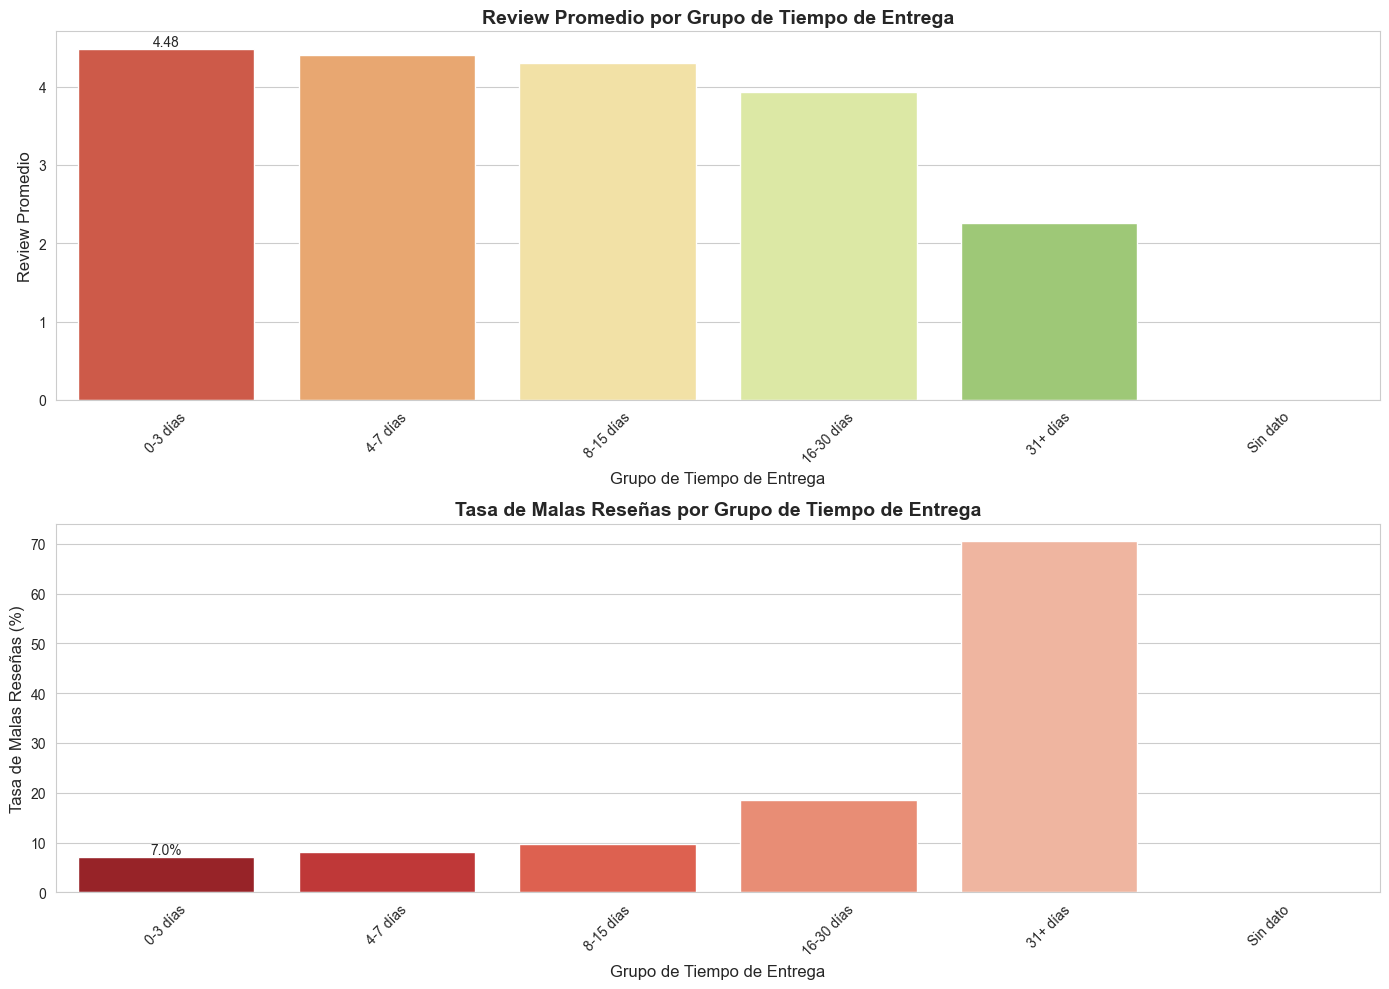

In [36]:
# Visualizar satisfacción por grupo de tiempo de entrega
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Review promedio por grupo de tiempo de entrega
sns.barplot(data=satisfaction_by_delivery_time_group, x='delivery_time_group', y='avg_review_score', ax=axes[0], palette='RdYlGn')
axes[0].set_title('Review Promedio por Grupo de Tiempo de Entrega', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Grupo de Tiempo de Entrega', fontsize=12)
axes[0].set_ylabel('Review Promedio', fontsize=12)
axes[0].bar_label(axes[0].containers[0], fmt='{:.2f}')
axes[0].tick_params(axis='x', rotation=45)

# Bad review rate por grupo de tiempo de entrega
sns.barplot(data=satisfaction_by_delivery_time_group, x='delivery_time_group', y='bad_review_rate', ax=axes[1], palette='Reds_r')
axes[1].set_title('Tasa de Malas Reseñas por Grupo de Tiempo de Entrega', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Grupo de Tiempo de Entrega', fontsize=12)
axes[1].set_ylabel('Tasa de Malas Reseñas (%)', fontsize=12)
axes[1].bar_label(axes[1].containers[0], fmt='{:.1f}%')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'satisfaction_by_delivery_time_group.png', dpi=300, bbox_inches='tight')
plt.show()

## 14. Impacto del flete en la satisfacción

In [37]:
# Crear grupos de freight_ratio usando quantiles
freight_ratio_q1 = satisfaction_base['freight_ratio'].quantile(0.25)
freight_ratio_q2 = satisfaction_base['freight_ratio'].quantile(0.50)
freight_ratio_q3 = satisfaction_base['freight_ratio'].quantile(0.75)

def categorize_freight_ratio(ratio):
    if pd.isna(ratio):
        return 'Sin dato'
    elif ratio <= freight_ratio_q1:
        return 'Muy bajo (Q1)'
    elif ratio <= freight_ratio_q2:
        return 'Bajo (Q1-Q2)'
    elif ratio <= freight_ratio_q3:
        return 'Medio (Q2-Q3)'
    else:
        return 'Alto (Q3+)'

satisfaction_base['freight_ratio_group'] = satisfaction_base['freight_ratio'].apply(categorize_freight_ratio)

# Agrupar por freight_ratio_group
satisfaction_by_freight_ratio_group = satisfaction_base.groupby('freight_ratio_group').agg(
    orders_with_review=('order_id', 'count'),
    avg_review_score=('review_score_avg', 'mean'),
    bad_review_rate=('bad_review', 'mean'),
    avg_freight_value=('total_freight', 'mean'),
    avg_freight_ratio=('freight_ratio', 'mean'),
    avg_payment_value=('payment_total', 'mean')
).reset_index()

satisfaction_by_freight_ratio_group['bad_review_rate'] = satisfaction_by_freight_ratio_group['bad_review_rate'] * 100

# Ordenar por freight_ratio_group según el orden lógico
freight_order = ['Muy bajo (Q1)', 'Bajo (Q1-Q2)', 'Medio (Q2-Q3)', 'Alto (Q3+)', 'Sin dato']
satisfaction_by_freight_ratio_group['freight_ratio_group'] = pd.Categorical(satisfaction_by_freight_ratio_group['freight_ratio_group'], categories=freight_order)
satisfaction_by_freight_ratio_group = satisfaction_by_freight_ratio_group.sort_values('freight_ratio_group')

print("Satisfacción por grupo de ratio de flete:")
print(satisfaction_by_freight_ratio_group)

# Guardar
satisfaction_by_freight_ratio_group.to_csv(REPORTS_DIR / 'satisfaction_by_freight_ratio_group.csv', index=False)
print(f"\nGuardado: {REPORTS_DIR / 'satisfaction_by_freight_ratio_group.csv'}")

Satisfacción por grupo de ratio de flete:
  freight_ratio_group  orders_with_review  avg_review_score  bad_review_rate  avg_freight_value  avg_freight_ratio  avg_payment_value
3       Muy bajo (Q1)               23959          4.200488        12.316875          19.931993           0.084178         316.269194
1        Bajo (Q1-Q2)               23966          4.164580        12.371693          21.249695           0.175627         144.581328
2       Medio (Q2-Q3)               23949          4.144933        13.002631          23.782983           0.291932         106.660363
0          Alto (Q3+)               23956          4.114077        13.399566          26.086695           0.682127          70.828948

Guardado: C:\Users\Samuel Vergara\Desktop\Apps\marketpulse-olist-commerce-intelligence\reports\satisfaction_by_freight_ratio_group.csv


C:\Users\Samuel Vergara\AppData\Local\Temp\ipykernel_3920\3404985942.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=satisfaction_by_freight_ratio_group, x='freight_ratio_group', y='avg_review_score', ax=axes[0], palette='RdYlGn')
C:\Users\Samuel Vergara\AppData\Local\Temp\ipykernel_3920\3404985942.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=satisfaction_by_freight_ratio_group, x='freight_ratio_group', y='bad_review_rate', ax=axes[1], palette='Reds_r')


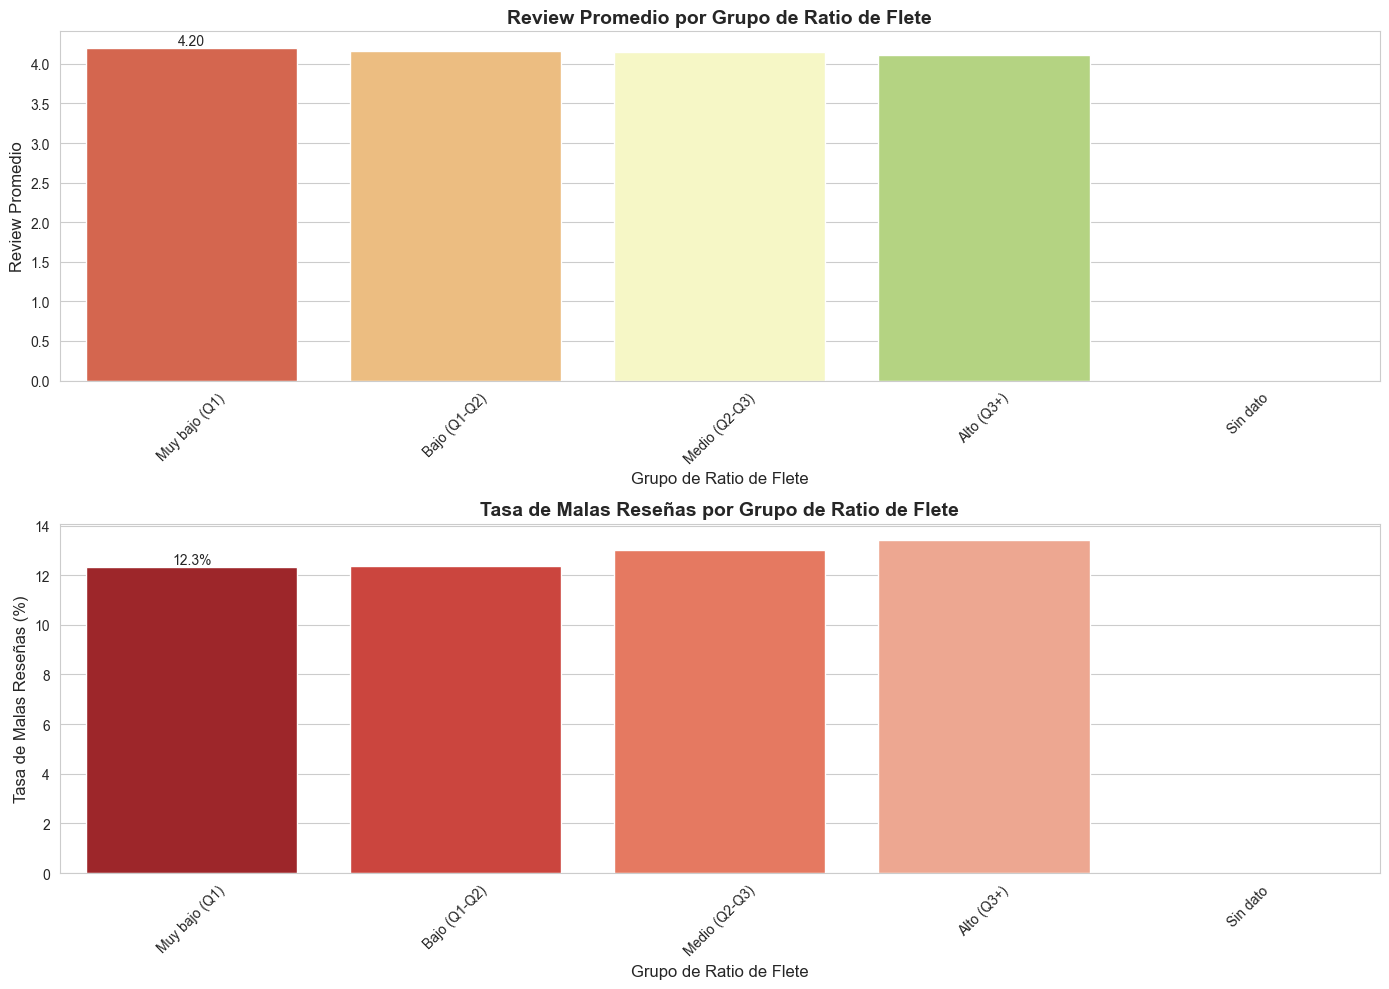

In [38]:
# Visualizar satisfacción por grupo de freight_ratio
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Review promedio por grupo de freight_ratio
sns.barplot(data=satisfaction_by_freight_ratio_group, x='freight_ratio_group', y='avg_review_score', ax=axes[0], palette='RdYlGn')
axes[0].set_title('Review Promedio por Grupo de Ratio de Flete', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Grupo de Ratio de Flete', fontsize=12)
axes[0].set_ylabel('Review Promedio', fontsize=12)
axes[0].bar_label(axes[0].containers[0], fmt='{:.2f}')
axes[0].tick_params(axis='x', rotation=45)

# Bad review rate por grupo de freight_ratio
sns.barplot(data=satisfaction_by_freight_ratio_group, x='freight_ratio_group', y='bad_review_rate', ax=axes[1], palette='Reds_r')
axes[1].set_title('Tasa de Malas Reseñas por Grupo de Ratio de Flete', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Grupo de Ratio de Flete', fontsize=12)
axes[1].set_ylabel('Tasa de Malas Reseñas (%)', fontsize=12)
axes[1].bar_label(axes[1].containers[0], fmt='{:.1f}%')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'satisfaction_by_freight_ratio_group.png', dpi=300, bbox_inches='tight')
plt.show()

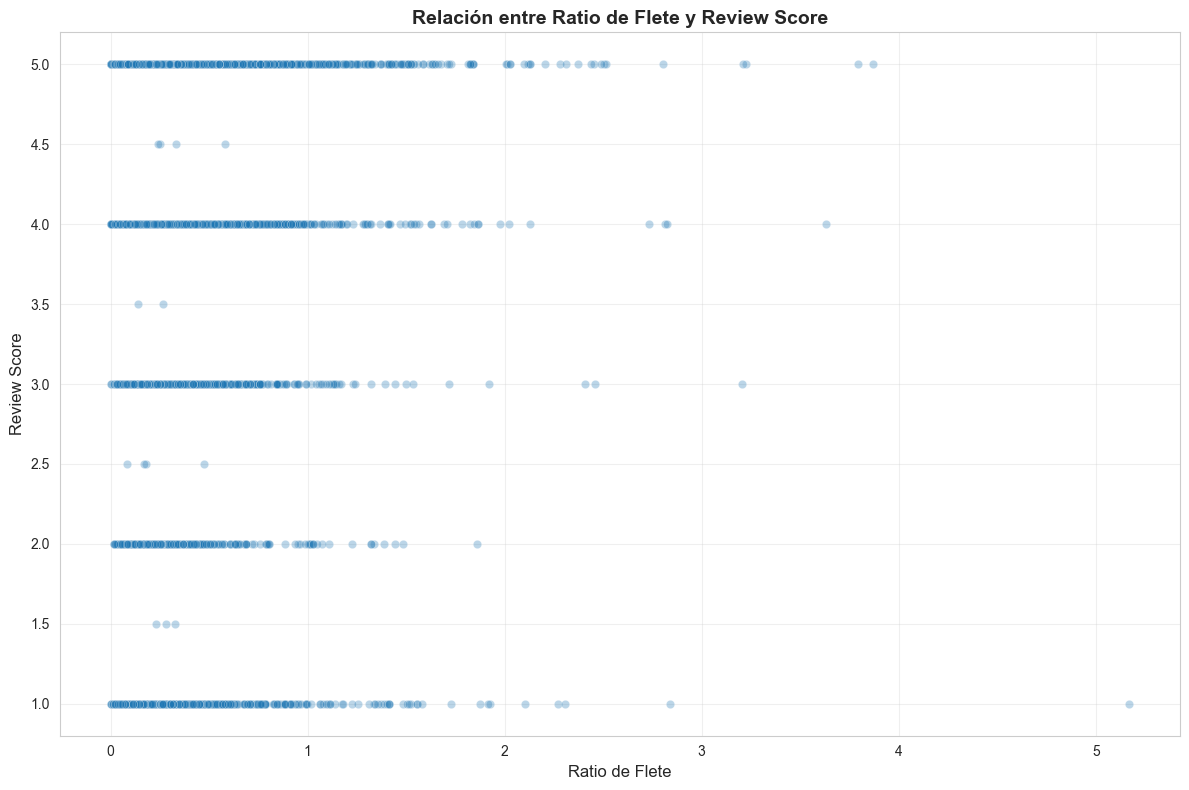

In [39]:
# Scatter freight_ratio vs review_score_avg
fig, ax = plt.subplots(figsize=(12, 8))
sample_data = satisfaction_base.sample(min(10000, len(satisfaction_base)), random_state=42)
sns.scatterplot(data=sample_data, x='freight_ratio', y='review_score_avg', alpha=0.3, ax=ax)
ax.set_title('Relación entre Ratio de Flete y Review Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Ratio de Flete', fontsize=12)
ax.set_ylabel('Review Score', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'freight_ratio_vs_review_score_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

## 15. Impacto de distancia cliente-vendedor

In [40]:
# Verificar si existe avg_distance_km en la base
if 'avg_distance_km' in df.columns:
    print("Variable avg_distance_km encontrada. Procediendo con análisis de distancia.")
    
    # Crear grupos de distancia
    def categorize_distance(km):
        if pd.isna(km):
            return 'Sin dato'
        elif km <= 100:
            return '0-100 km'
        elif km <= 300:
            return '100-300 km'
        elif km <= 600:
            return '300-600 km'
        elif km <= 1000:
            return '600-1000 km'
        else:
            return '1000+ km'
    
    satisfaction_base['distance_range'] = satisfaction_base['avg_distance_km'].apply(categorize_distance)
    
    # Agrupar por distance_range
    satisfaction_by_distance_range = satisfaction_base.groupby('distance_range').agg(
        orders_with_review=('order_id', 'count'),
        avg_distance_km=('avg_distance_km', 'mean'),
        avg_review_score=('review_score_avg', 'mean'),
        bad_review_rate=('bad_review', 'mean'),
        avg_delivery_time_days=('delivery_time_days', 'mean'),
        late_delivery_rate=('is_late', 'mean'),
        avg_freight_value=('total_freight', 'mean')
    ).reset_index()
    
    satisfaction_by_distance_range['bad_review_rate'] = satisfaction_by_distance_range['bad_review_rate'] * 100
    satisfaction_by_distance_range['late_delivery_rate'] = satisfaction_by_distance_range['late_delivery_rate'] * 100
    
    # Ordenar por distance_range según el orden lógico
    distance_order = ['0-100 km', '100-300 km', '300-600 km', '600-1000 km', '1000+ km', 'Sin dato']
    satisfaction_by_distance_range['distance_range'] = pd.Categorical(satisfaction_by_distance_range['distance_range'], categories=distance_order)
    satisfaction_by_distance_range = satisfaction_by_distance_range.sort_values('distance_range')
    
    print("Satisfacción por rango de distancia:")
    print(satisfaction_by_distance_range)
    
    # Guardar
    satisfaction_by_distance_range.to_csv(REPORTS_DIR / 'satisfaction_by_distance_range.csv', index=False)
    print(f"\nGuardado: {REPORTS_DIR / 'satisfaction_by_distance_range.csv'}")
    
    has_distance_data = True
else:
    print("Variable avg_distance_km no encontrada en la base.")
    has_distance_data = False

Variable avg_distance_km encontrada. Procediendo con análisis de distancia.
Satisfacción por rango de distancia:
  distance_range  orders_with_review  avg_distance_km  avg_review_score  bad_review_rate  avg_delivery_time_days  late_delivery_rate  avg_freight_value
0       0-100 km               17714        40.078240          4.277878        10.274359                6.499201            6.373490          13.343576
1     100-300 km               13342       200.360727          4.240519        10.972868                9.942699            6.288413          18.825331
3     300-600 km               31278       430.036197          4.134402        13.360829               12.581294            7.663533          22.376043
4    600-1000 km               17803       784.552106          4.120429        13.250576               14.679388            8.330057          24.803929
2       1000+ km               15218      1737.842131          4.024938        15.527665               19.060311           11.5

C:\Users\Samuel Vergara\AppData\Local\Temp\ipykernel_3920\195183516.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=satisfaction_by_distance_range, x='distance_range', y='avg_review_score', ax=axes[0], palette='RdYlGn')
C:\Users\Samuel Vergara\AppData\Local\Temp\ipykernel_3920\195183516.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=satisfaction_by_distance_range, x='distance_range', y='bad_review_rate', ax=axes[1], palette='Reds_r')


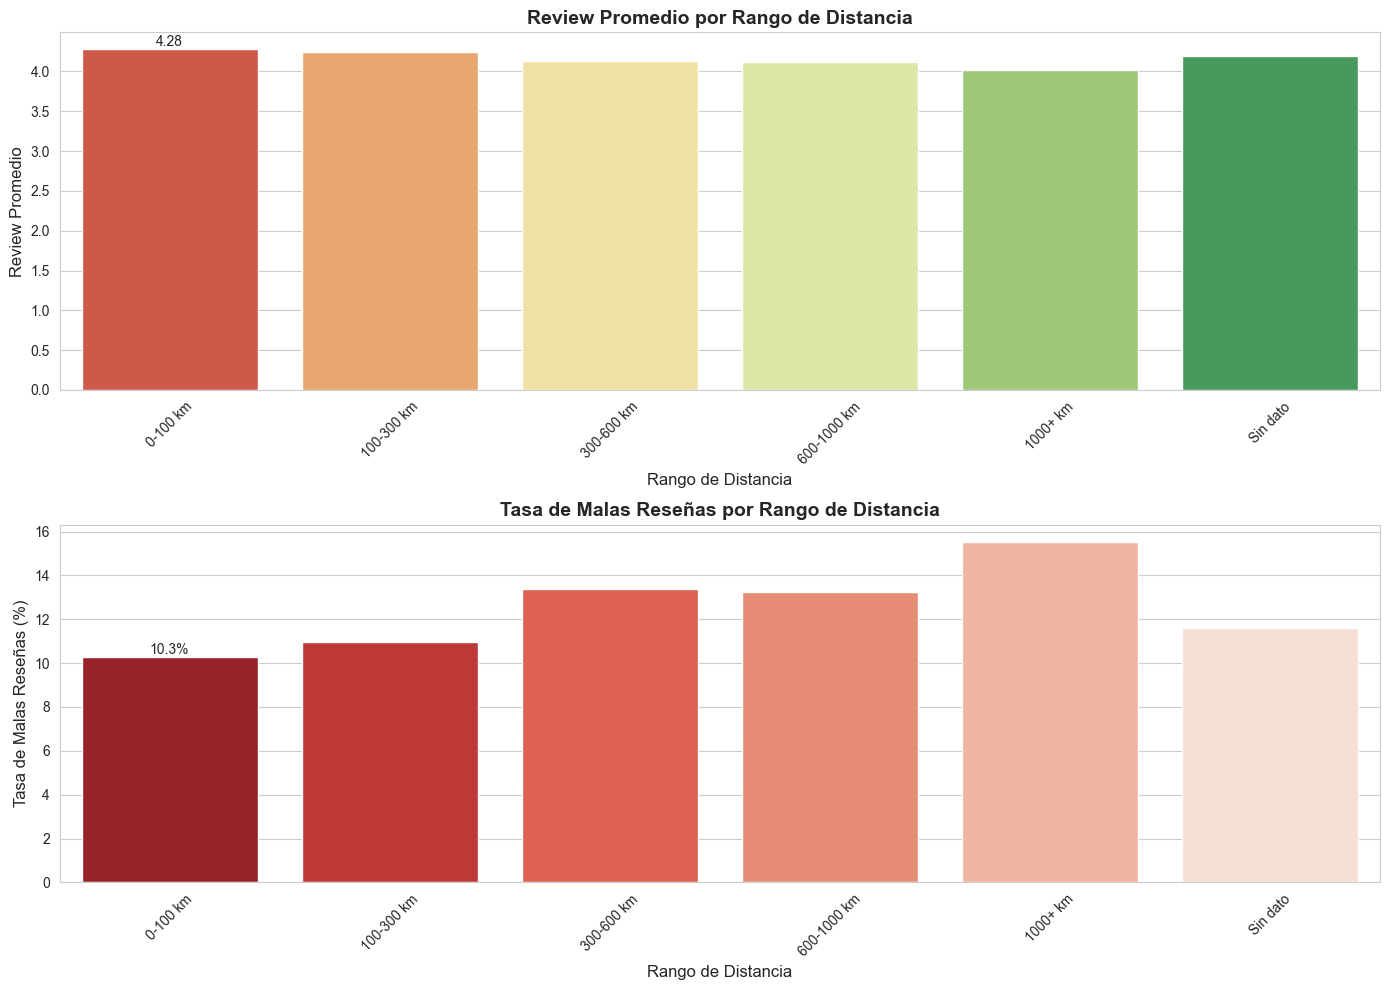

In [41]:
# Visualizar satisfacción por rango de distancia (solo si existe data)
if has_distance_data:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Review promedio por rango de distancia
    sns.barplot(data=satisfaction_by_distance_range, x='distance_range', y='avg_review_score', ax=axes[0], palette='RdYlGn')
    axes[0].set_title('Review Promedio por Rango de Distancia', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Rango de Distancia', fontsize=12)
    axes[0].set_ylabel('Review Promedio', fontsize=12)
    axes[0].bar_label(axes[0].containers[0], fmt='{:.2f}')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Bad review rate por rango de distancia
    sns.barplot(data=satisfaction_by_distance_range, x='distance_range', y='bad_review_rate', ax=axes[1], palette='Reds_r')
    axes[1].set_title('Tasa de Malas Reseñas por Rango de Distancia', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Rango de Distancia', fontsize=12)
    axes[1].set_ylabel('Tasa de Malas Reseñas (%)', fontsize=12)
    axes[1].bar_label(axes[1].containers[0], fmt='{:.1f}%')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'satisfaction_by_distance_range.png', dpi=300, bbox_inches='tight')
    plt.show()

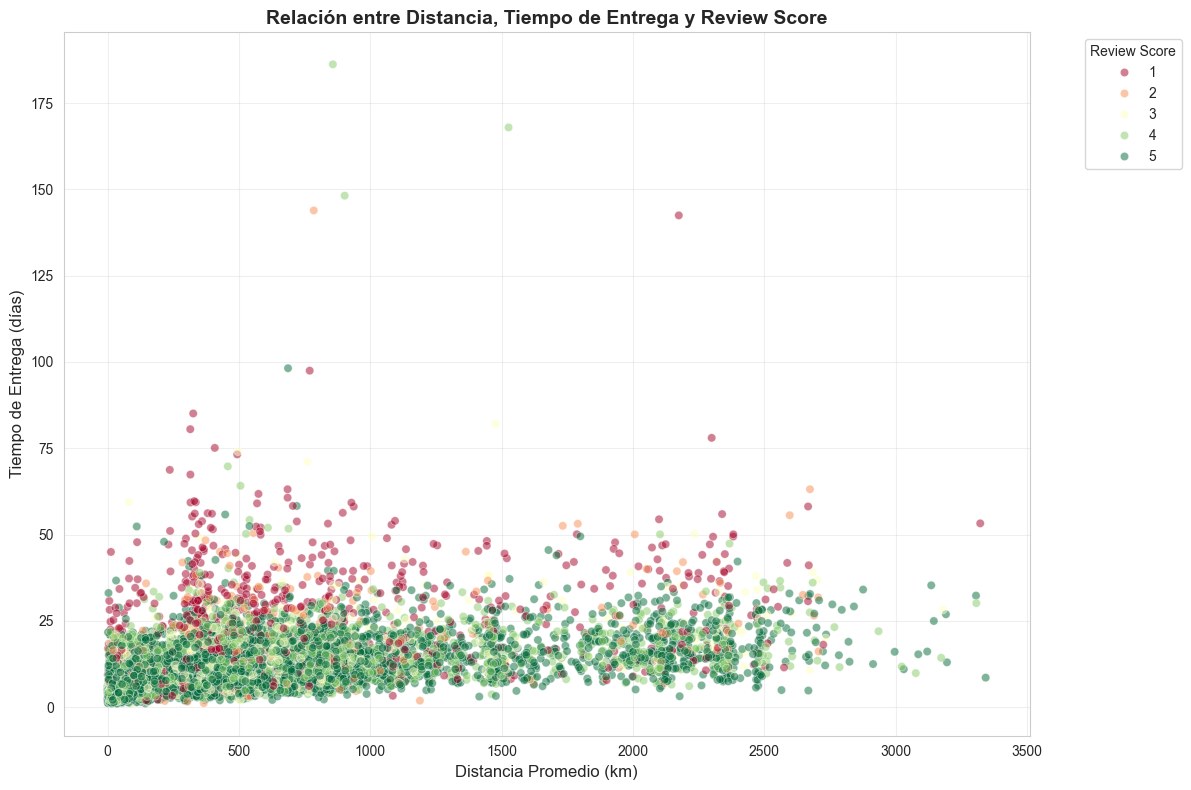

In [42]:
# Relación entre distancia, tiempo de entrega y review (solo si existe data)
if has_distance_data:
    fig, ax = plt.subplots(figsize=(12, 8))
    sample_data = satisfaction_base.sample(min(10000, len(satisfaction_base)), random_state=42)
    sns.scatterplot(data=sample_data, x='avg_distance_km', y='delivery_time_days', 
                    hue='review_score_rounded', palette='RdYlGn', alpha=0.5, ax=ax)
    ax.set_title('Relación entre Distancia, Tiempo de Entrega y Review Score', fontsize=14, fontweight='bold')
    ax.set_xlabel('Distancia Promedio (km)', fontsize=12)
    ax.set_ylabel('Tiempo de Entrega (días)', fontsize=12)
    ax.legend(title='Review Score', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'distance_delivery_time_review.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No se puede generar visualización de distancia: avg_distance_km no disponible")

**Nota:** Si avg_distance_km no existe, este análisis requiere ejecutar primero notebooks/05_analisis_logistico.ipynb para generar la variable de distancia.

## 16. Comentarios de reseñas

In [43]:
# Analizar existencia de comentarios
if 'has_review_comment' in satisfaction_base.columns:
    # Comparar review promedio con y sin comentario
    comment_comparison = satisfaction_base.groupby('has_review_comment').agg(
        orders_with_review=('order_id', 'count'),
        avg_review_score=('review_score_avg', 'mean'),
        bad_review_rate=('bad_review', 'mean')
    ).reset_index()
    
    comment_comparison['bad_review_rate'] = comment_comparison['bad_review_rate'] * 100
    comment_comparison['has_review_comment'] = comment_comparison['has_review_comment'].map({0: 'Sin comentario', 1: 'Con comentario'})
    
    print("Comparación de satisfacción según presencia de comentario:")
    print(comment_comparison)
    
    # Guardar
    comment_comparison.to_csv(REPORTS_DIR / 'satisfaction_comment_presence.csv', index=False)
    print(f"\nGuardado: {REPORTS_DIR / 'satisfaction_comment_presence.csv'}")
else:
    print("Variable has_review_comment no encontrada en la base")
    comment_comparison = None

Comparación de satisfacción según presencia de comentario:
  has_review_comment  orders_with_review  avg_review_score  bad_review_rate
0     Sin comentario               56867          4.417418         5.317671
1     Con comentario               38963          3.774513        23.653209

Guardado: C:\Users\Samuel Vergara\Desktop\Apps\marketpulse-olist-commerce-intelligence\reports\satisfaction_comment_presence.csv


C:\Users\Samuel Vergara\AppData\Local\Temp\ipykernel_3920\1863519448.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comment_comparison, x='has_review_comment', y='orders_with_review', ax=axes[0], palette='viridis')
C:\Users\Samuel Vergara\AppData\Local\Temp\ipykernel_3920\1863519448.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comment_comparison, x='has_review_comment', y='avg_review_score', ax=axes[1], palette='RdYlGn')


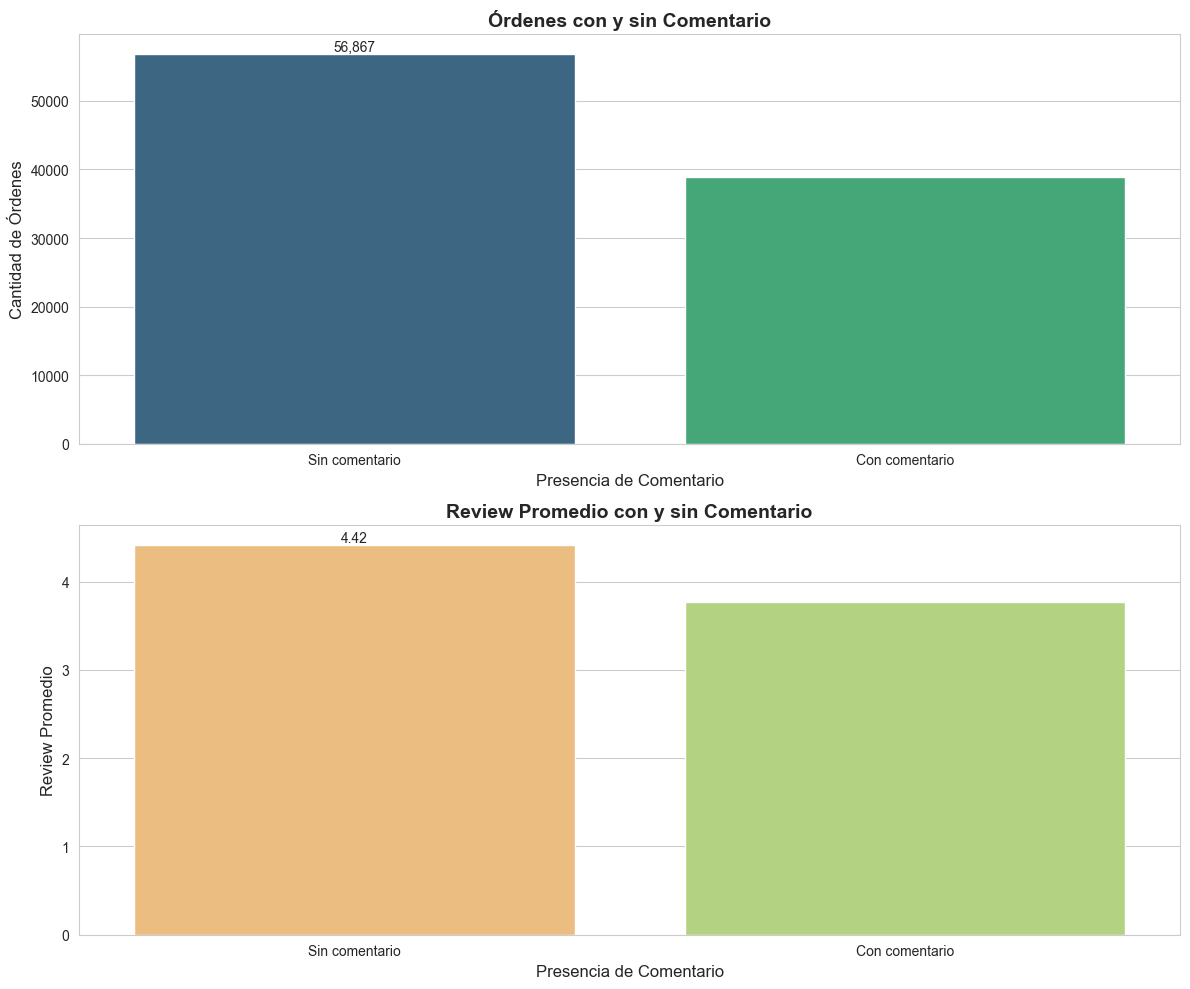

In [44]:
# Visualizar comparación de comentarios (solo si existe data)
if comment_comparison is not None:
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    
    # Órdenes con y sin comentario
    sns.barplot(data=comment_comparison, x='has_review_comment', y='orders_with_review', ax=axes[0], palette='viridis')
    axes[0].set_title('Órdenes con y sin Comentario', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Presencia de Comentario', fontsize=12)
    axes[0].set_ylabel('Cantidad de Órdenes', fontsize=12)
    axes[0].bar_label(axes[0].containers[0], fmt='{:,.0f}')
    
    # Review promedio con y sin comentario
    sns.barplot(data=comment_comparison, x='has_review_comment', y='avg_review_score', ax=axes[1], palette='RdYlGn')
    axes[1].set_title('Review Promedio con y sin Comentario', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Presencia de Comentario', fontsize=12)
    axes[1].set_ylabel('Review Promedio', fontsize=12)
    axes[1].bar_label(axes[1].containers[0], fmt='{:.2f}')
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'satisfaction_comment_presence.png', dpi=300, bbox_inches='tight')
    plt.show()

C:\Users\Samuel Vergara\AppData\Local\Temp\ipykernel_3920\3949022525.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comment_comparison, x='has_review_comment', y='bad_review_rate', palette='Reds_r')


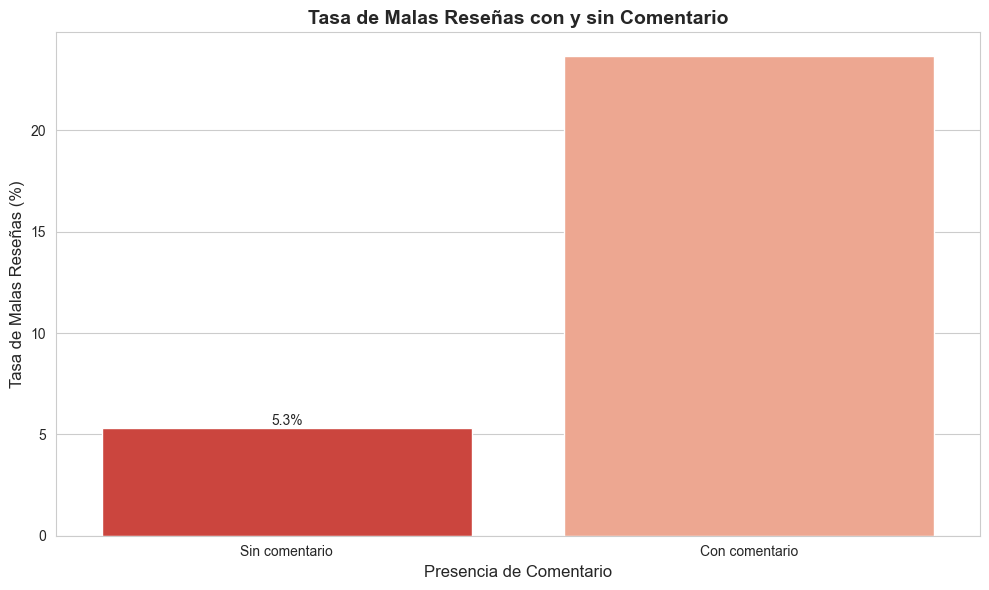

In [45]:
# Bad review rate con y sin comentario (solo si existe data)
if comment_comparison is not None:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=comment_comparison, x='has_review_comment', y='bad_review_rate', palette='Reds_r')
    plt.title('Tasa de Malas Reseñas con y sin Comentario', fontsize=14, fontweight='bold')
    plt.xlabel('Presencia de Comentario', fontsize=12)
    plt.ylabel('Tasa de Malas Reseñas (%)', fontsize=12)
    plt.bar_label(plt.gca().containers[0], fmt='{:.1f}%')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'bad_review_rate_by_comment_presence.png', dpi=300, bbox_inches='tight')
    plt.show()

## 17. Perfil de malas reseñas

In [46]:
# Crear dataframe bad_reviews_profile
bad_reviews_profile = satisfaction_base[satisfaction_base['bad_review'] == 1].copy()

print(f"Órdenes con malas reseñas: {len(bad_reviews_profile):,}")
print(f"Porcentaje de órdenes con reseña: {len(bad_reviews_profile) / len(satisfaction_base) * 100:.2f}%")

# Variables para comparación
comparison_vars = [
    'payment_total',
    'total_price',
    'total_freight',
    'freight_ratio',
    'delivery_time_days',
    'delivery_delay_days',
    'items_count',
    'sellers_count'
]

if 'avg_distance_km' in satisfaction_base.columns:
    comparison_vars.append('avg_distance_km')

# Calcular resumen comparativo
bad_vs_good_comparison = []
for var in comparison_vars:
    if var in satisfaction_base.columns:
        bad_avg = satisfaction_base[satisfaction_base['bad_review'] == 1][var].mean()
        good_avg = satisfaction_base[satisfaction_base['bad_review'] == 0][var].mean()
        diff = bad_avg - good_avg
        bad_vs_good_comparison.append({
            'variable': var,
            'promedio_bad_review': bad_avg,
            'promedio_good_review': good_avg,
            'diferencia': diff
        })

bad_vs_good_review_comparison = pd.DataFrame(bad_vs_good_comparison)

print("\nComparación entre malas y buenas reseñas:")
print(bad_vs_good_review_comparison)

# Guardar
bad_vs_good_review_comparison.to_csv(REPORTS_DIR / 'bad_vs_good_review_comparison.csv', index=False)
print(f"\nGuardado: {REPORTS_DIR / 'bad_vs_good_review_comparison.csv'}")

Órdenes con malas reseñas: 12,240
Porcentaje de órdenes con reseña: 12.77%

Comparación entre malas y buenas reseñas:
              variable  promedio_bad_review  promedio_good_review  diferencia
0        payment_total           187.941896            155.439405   32.502490
1          total_price           160.177029            133.375090   26.801939
2        total_freight            27.721628             22.036363    5.685265
3        freight_ratio             0.320467              0.306686    0.013782
4   delivery_time_days            20.223422             11.388850    8.834572
5  delivery_delay_days            -4.433917            -12.209336    7.775419
6          items_count             1.316503              1.115624    0.200879
7        sellers_count             1.052369              1.008207    0.044163
8      avg_distance_km           672.435201            589.804866   82.630335

Guardado: C:\Users\Samuel Vergara\Desktop\Apps\marketpulse-olist-commerce-intelligence\reports\bad_vs

C:\Users\Samuel Vergara\AppData\Local\Temp\ipykernel_3920\1471281763.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=satisfaction_base, x='bad_review', y='delivery_time_days', palette='RdYlGn')


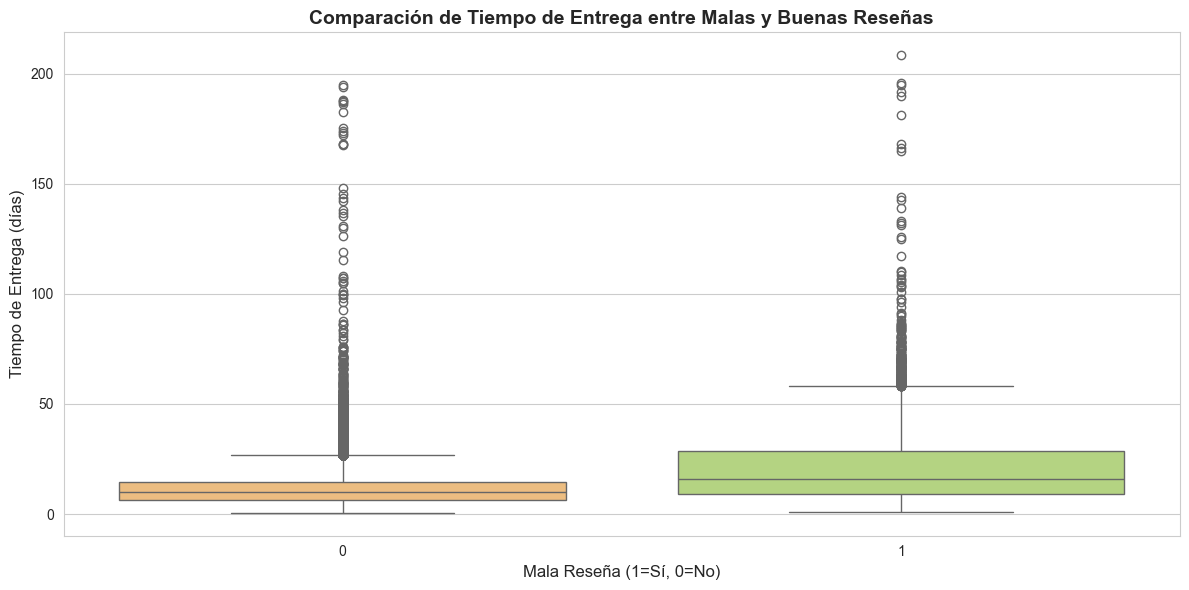

In [47]:
# Comparación de delivery_time_days entre malas y buenas reseñas
plt.figure(figsize=(12, 6))
sns.boxplot(data=satisfaction_base, x='bad_review', y='delivery_time_days', palette='RdYlGn')
plt.title('Comparación de Tiempo de Entrega entre Malas y Buenas Reseñas', fontsize=14, fontweight='bold')
plt.xlabel('Mala Reseña (1=Sí, 0=No)', fontsize=12)
plt.ylabel('Tiempo de Entrega (días)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'delivery_time_by_bad_review.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Samuel Vergara\AppData\Local\Temp\ipykernel_3920\2637455644.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=satisfaction_base, x='bad_review', y='delivery_delay_days', palette='RdYlGn')


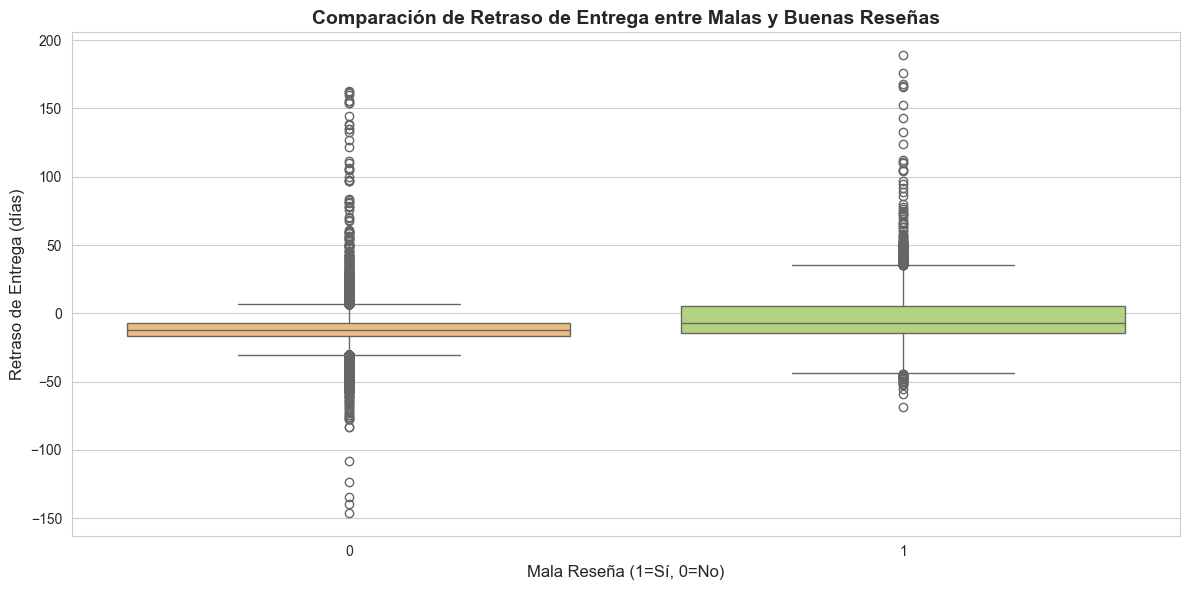

In [48]:
# Comparación de delivery_delay_days entre malas y buenas reseñas
plt.figure(figsize=(12, 6))
sns.boxplot(data=satisfaction_base, x='bad_review', y='delivery_delay_days', palette='RdYlGn')
plt.title('Comparación de Retraso de Entrega entre Malas y Buenas Reseñas', fontsize=14, fontweight='bold')
plt.xlabel('Mala Reseña (1=Sí, 0=No)', fontsize=12)
plt.ylabel('Retraso de Entrega (días)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'delivery_delay_by_bad_review.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Samuel Vergara\AppData\Local\Temp\ipykernel_3920\22347946.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=satisfaction_base, x='bad_review', y='freight_ratio', palette='RdYlGn')


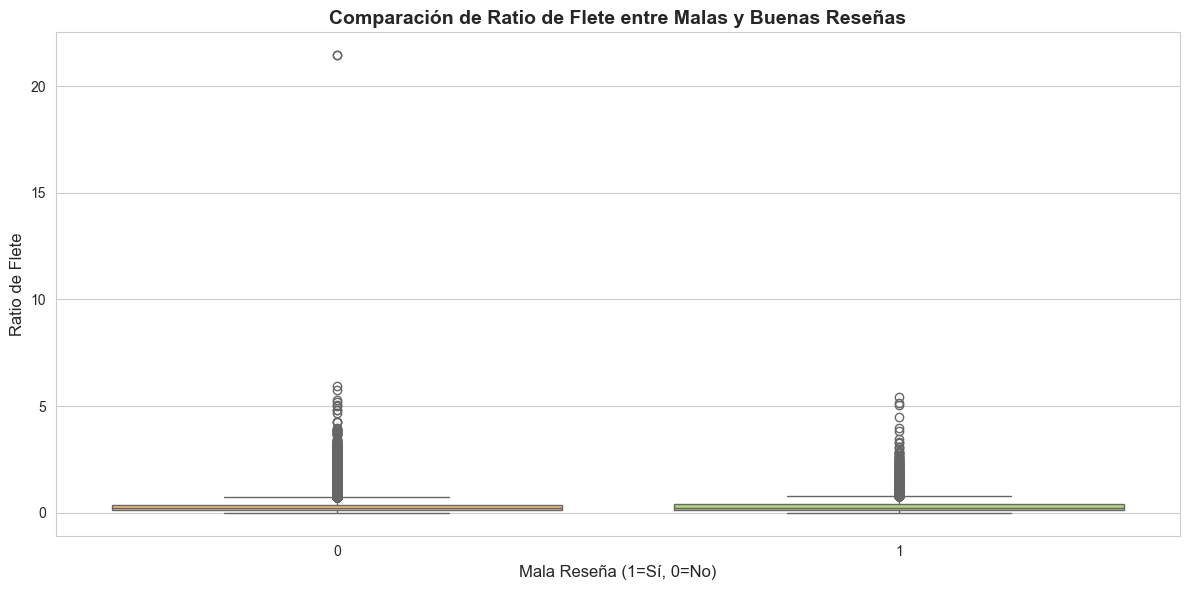

In [49]:
# Comparación de freight_ratio entre malas y buenas reseñas
plt.figure(figsize=(12, 6))
sns.boxplot(data=satisfaction_base, x='bad_review', y='freight_ratio', palette='RdYlGn')
plt.title('Comparación de Ratio de Flete entre Malas y Buenas Reseñas', fontsize=14, fontweight='bold')
plt.xlabel('Mala Reseña (1=Sí, 0=No)', fontsize=12)
plt.ylabel('Ratio de Flete', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'freight_ratio_by_bad_review.png', dpi=300, bbox_inches='tight')
plt.show()

## 18. Tablas finales para dashboard

In [50]:
# Crear tabla dashboard_satisfaction_summary
dashboard_satisfaction_summary = satisfaction_kpi_summary.copy()
dashboard_satisfaction_summary.columns = [
    'total_ordenes',
    'ordenes_con_resena',
    'tasa_cobertura_resena',
    'review_promedio',
    'review_mediana',
    'ordenes_mala_resena',
    'tasa_mala_resena',
    'ordenes_buena_resena',
    'tasa_buena_resena',
    'ordenes_con_comentario',
    'tasa_comentario'
]

dashboard_satisfaction_summary.to_csv(REPORTS_DIR / 'dashboard_satisfaction_summary.csv', index=False)
print("Guardado: dashboard_satisfaction_summary.csv")
print(dashboard_satisfaction_summary.T)

Guardado: dashboard_satisfaction_summary.csv
                                   0
total_ordenes           96476.000000
ordenes_con_resena      95830.000000
tasa_cobertura_resena      99.330403
review_promedio             4.156023
review_mediana              5.000000
ordenes_mala_resena     12240.000000
tasa_mala_resena           12.772618
ordenes_buena_resena    75620.000000
tasa_buena_resena          78.910571
ordenes_con_comentario  38963.000000
tasa_comentario            40.658458


In [51]:
# Crear tabla dashboard_satisfaction_by_month
dashboard_satisfaction_by_month = monthly_satisfaction_metrics.copy()
dashboard_satisfaction_by_month.columns = [
    'mes',
    'ordenes_con_resena',
    'review_promedio',
    'tasa_mala_resena',
    'tasa_buena_resena',
    'tasa_comentario'
]

dashboard_satisfaction_by_month.to_csv(REPORTS_DIR / 'dashboard_satisfaction_by_month.csv', index=False)
print("Guardado: dashboard_satisfaction_by_month.csv")
print(dashboard_satisfaction_by_month.head())

Guardado: dashboard_satisfaction_by_month.csv
       mes  ordenes_con_resena  review_promedio  tasa_mala_resena  tasa_buena_resena  tasa_comentario
0  2016-09                   1         1.000000        100.000000           0.000000       100.000000
1  2016-10                 267         3.970037         17.602996          74.531835        70.411985
2  2016-12                   1         5.000000          0.000000         100.000000       100.000000
3  2017-01                 741         4.199055         12.010796          79.757085        44.939271
4  2017-02                1643         4.202678         11.077298          79.306147        44.065733


In [52]:
# Crear tabla dashboard_satisfaction_by_category
dashboard_satisfaction_by_category = satisfaction_by_category.copy()
dashboard_satisfaction_by_category.columns = [
    'categoria',
    'ordenes_con_resena',
    'review_promedio',
    'tasa_mala_resena',
    'tasa_buena_resena',
    'tiempo_entrega_promedio_dias',
    'tasa_entrega_tardia',
    'flete_promedio',
    'ratio_flete_promedio',
    'tasa_comentario'
]

dashboard_satisfaction_by_category.to_csv(REPORTS_DIR / 'dashboard_satisfaction_by_category.csv', index=False)
print("Guardado: dashboard_satisfaction_by_category.csv")
print(dashboard_satisfaction_by_category.head())

Guardado: dashboard_satisfaction_by_category.csv
                    categoria  ordenes_con_resena  review_promedio  tasa_mala_resena  tasa_buena_resena  tiempo_entrega_promedio_dias  tasa_entrega_tardia  flete_promedio  ratio_flete_promedio  tasa_comentario
0  agro_industry_and_commerce                 177         4.107345         12.429379          80.225989                     11.432300             5.084746       31.848588              0.238226        31.073446
1            air_conditioning                 242         4.115702         14.049587          78.099174                     11.802783             3.719008       26.762190              0.220740        40.082645
2                         art                 192         4.114583         13.541667          77.083333                     11.185249             7.812500       20.058073              0.275777        43.750000
3       arts_and_craftmanship                  23         4.173913         13.043478          78.260870        

In [53]:
# Crear tabla dashboard_satisfaction_by_state
dashboard_satisfaction_by_state = satisfaction_by_state.copy()
dashboard_satisfaction_by_state.columns = [
    'estado_cliente',
    'ordenes_con_resena',
    'review_promedio',
    'tasa_mala_resena',
    'tasa_buena_resena',
    'tiempo_entrega_promedio_dias',
    'tasa_entrega_tardia',
    'flete_promedio',
    'ratio_flete_promedio',
    'tasa_comentario'
]

dashboard_satisfaction_by_state.to_csv(REPORTS_DIR / 'dashboard_satisfaction_by_state.csv', index=False)
print("Guardado: dashboard_satisfaction_by_state.csv")
print(dashboard_satisfaction_by_state.head())

Guardado: dashboard_satisfaction_by_state.csv
  estado_cliente  ordenes_con_resena  review_promedio  tasa_mala_resena  tasa_buena_resena  tiempo_entrega_promedio_dias  tasa_entrega_tardia  flete_promedio  ratio_flete_promedio  tasa_comentario
0             AC                  80         4.087500         15.000000          75.000000                     21.035713             3.750000       45.554500              0.510257        46.250000
1             AL                 394         3.852792         21.065990          71.573604                     24.457127            23.350254       38.580279              0.468130        47.969543
2             AM                 144         4.243056         13.194444          82.638889                     26.352644             4.166667       37.528542              0.505093        43.055556
3             AP                  66         4.242424          6.060606          81.818182                     27.121586             4.545455       41.553333         

In [54]:
# Crear tabla dashboard_satisfaction_by_delay_group
dashboard_satisfaction_by_delay_group = satisfaction_by_delay_group.copy()
dashboard_satisfaction_by_delay_group.columns = [
    'grupo_retraso',
    'ordenes_con_resena',
    'review_promedio',
    'tasa_mala_resena',
    'tasa_buena_resena'
]

dashboard_satisfaction_by_delay_group.to_csv(REPORTS_DIR / 'dashboard_satisfaction_by_delay_group.csv', index=False)
print("Guardado: dashboard_satisfaction_by_delay_group.csv")
print(dashboard_satisfaction_by_delay_group)

Guardado: dashboard_satisfaction_by_delay_group.csv
              grupo_retraso  ordenes_con_resena  review_promedio  tasa_mala_resena  tasa_buena_resena
0                Anticipada               88168         4.294151          9.995560          82.764722
2   Retraso leve (1-3 días)                1356         3.513274         30.060817          59.365782
3  Retraso medio (4-7 días)                1277         2.175020         72.758921          24.510572
1    Retraso alto (8+ días)                5029         2.410718         65.878680          30.423543
